# Support Ticket → Department Classifier

**Goal:** given the text of a customer support ticket, predict which department should handle it.

> **Update — the target changed part-way through.** The investigation in Phases 1–4 found that this dataset's
> department labels do not reliably match the ticket text. The **Checkpoint** after Phase 4 lays out the evidence
> and explains the switch: the model is built to predict the ticket's **type** (Incident, Request, Problem, Change)
> instead. The department work is kept in full — it is how the problem was found.

**Dataset:** [Multilingual Customer Support Tickets](https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets) — Kaggle, `tobiasbueck/multilingual-customer-support-tickets`.
28,587 tickets in English and German, 16 columns. The label is `queue`, which holds the department name.
The model is built on the 16,338 English tickets (Step 8 explains why).

**The 10 departments:** Technical Support, Product Support, Customer Service, IT Support,
Billing and Payments, Returns and Exchanges, Service Outages and Maintenance, Sales and Pre-Sales,
Human Resources, General Inquiry. *(Counts and balance are examined in Step 4.)*

> **This is topic classification, not sentiment analysis.** We are sorting tickets into
> departments, not measuring whether the customer is happy or angry. Worth stating up front
> because it changes which metrics matter.

---

### Pipeline map

| Steps | Phase | What happens |
|---|---|---|
| 1–4 | **Understand** | Setup, load, inspect, check which columns could leak the answer, study the label |
| 5–10 | **Clean** | Build text, drop empty rows, check duplicates, English only, light cleaning, find families of reworded tickets |
| 11–14 | **Prepare** | Rare classes, split whole families, vectorize, handle imbalance |
| 15–16 | **Baseline** | Train 4 models, compare them fairly, show what a standard random split would have claimed |
| ✓ | **Checkpoint** | Test whether the target column can be learned at all — department can't, type can; switch target |
| 17–19 | **Improve** | Tune, analyse errors, fix confidence scores |
| 20 | **Finalize** | Test once, save, document limitations |

### One rule that runs through all of it

Anything learned from data — vocabulary, weights, scaling, resampling — is fitted on the
**training set only**. The moment test data influences training, the final score stops
meaning anything.

---

# Phase 1 — Understand the data
*Steps 1 to 4*

> **Phase 1 is descriptive.** It looks at all 28,587 tickets — including the ones that will later
> become the test set. That is acceptable only because nothing measured here is fed into the model:
> no vocabulary, no weights, no thresholds. The floors in Step 4 describe the raw data; the floors
> that actually judge models are recomputed on the validation and test sets in Steps 15 and 20.

## Step 1 — Setup

Imports, plotting defaults, one fixed random seed, and a record of library versions.

**Why the seed matters:** without it, every re-run shuffles the data differently and gives
slightly different numbers. You then can't tell whether a change actually improved the model
or whether you just got lucky. Fix it once, use it everywhere.

**Why record versions:** the model saved in Step 20 is only guaranteed to load under the same
scikit-learn version. The versions printed here go straight into the model card.

In [1]:
# Step 1 — imports, seed, display settings
import random
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("data")
LABEL = "queue"
TEXT_COLS = ["subject", "body"]

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

# Chart palette — colour-blind-safe categorical order (validated), one-hue blue ramp for magnitudes
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlecolor": INK,
    "legend.frameon": False,
})

ENV_VERSIONS = {
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": mpl.__version__,
    "seaborn": sns.__version__,
}
print(f"SEED = {SEED}")
print(" | ".join(f"{k} {v}" for k, v in ENV_VERSIONS.items()))

SEED = 42
python 3.11.14 | pandas 3.0.6 | numpy 2.4.6 | scikit-learn 1.9.1 | matplotlib 3.11.2 | seaborn 0.13.2


## Step 2 — Load the data

Download the dataset from
[Kaggle — Multilingual Customer Support Tickets](https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets)
and put the CSV in a `data/` folder next to this notebook.

**The Kaggle page offers several CSV files** — different versions and sizes of the same dataset.
This notebook uses **`aa_dataset-tickets-multi-lang-5-2-50-version.csv`**, the multi-language
release. The cell lists whatever is in `data/`, then loads that file by name, so the choice is
explicit rather than whichever file happened to be picked up first.

Keep the loaded version as `df_raw` and never modify it — all cleaning happens on copies, so we
can always compare back to the original.

> **Caveat to carry through the whole project:** this dataset is **synthetic** — the tickets were
> generated, not collected from real customers. A model can score well by learning the generator's
> writing style. Good results here show the *method* works; they do not prove the model would work
> on a real support inbox. This goes in the model card.

In [2]:
# Step 2 — load CSV into df_raw
print("CSV files in data/:")
for f in sorted(DATA_DIR.glob("*.csv")):
    print(f"  {f.name:50s} {f.stat().st_size / 1e6:6.1f} MB")

DATA_FILE = DATA_DIR / "aa_dataset-tickets-multi-lang-5-2-50-version.csv"
df_raw = pd.read_csv(DATA_FILE)

assert LABEL in df_raw.columns, f"label column '{LABEL}' missing from {DATA_FILE.name}"
assert set(TEXT_COLS) <= set(df_raw.columns), f"text columns {TEXT_COLS} missing from {DATA_FILE.name}"

print(f"\nLoaded {DATA_FILE.name}: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

CSV files in data/:
  aa_dataset-tickets-multi-lang-5-2-50-version.csv     26.0 MB

Loaded aa_dataset-tickets-multi-lang-5-2-50-version.csv: 28,587 rows × 16 columns


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komp...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroff...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management ...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, ...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed informati...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit....",Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


## Step 3 — Inspect what we actually have

Before touching anything, look at:

- **Shape** — how many rows (depth) and columns (width)
- **Column names and types** — what's text, what's categorical, what's a date
- **Missing values** — which columns have gaps, and how big
- **Unique counts** — a column with 1 unique value is useless; one with 28,000 is an ID

Surprises are much cheaper to find now than after training a model on them.

### Which columns would exist when a ticket arrives?

This is the most common way text classifiers end up with scores that are too good to be true.

The dataset has more than the ticket text. It also has the agent's **answer**, the ticket
**type**, its **priority**, and several **tags**. A support agent adds those *after* reading and
handling the ticket. When a new ticket arrives and needs routing, none of them exist yet.

If the model is allowed to see them, it gets credit in the notebook for information it will
never have in production — and the reported score overstates what it can really do.

So each column gets tagged as either:

| Tag | Meaning | Allowed as model input? |
|---|---|---|
| **available at routing** | Exists the moment the customer submits the ticket | Yes |
| **added after handling** | Filled in by an agent or a system later | **No** |

Only the first group — collected in `ROUTING_COLS` — is ever allowed near the model.

After the audit, three charts and a probe check the decision against the data: where the gaps are,
how much each excluded column would give away on its own and all together, and whether the
dataset's generation batches differ.

In [3]:
# Step 3 — shape, dtypes, missing values, unique counts
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

profile = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(1),
    "unique": df_raw.nunique(),
    "example": df_raw.apply(lambda col: col.dropna().iloc[0]).astype(str).str[:50],
})
profile

Shape: 28,587 rows × 16 columns


,dtype,missing,missing_%,unique,example
subject,str,3838,13.4,24749,Wesentlicher Sicherheitsvorfall
body,str,0,0.0,28587,"Sehr geehrtes Support-Team,\n\nich möchte einen gr"
answer,str,7,0.0,28580,Vielen Dank für die Meldung des kritischen Sicherh
type,str,0,0.0,4,Incident
queue,str,0,0.0,10,Technical Support
priority,str,0,0.0,3,high
language,str,0,0.0,2,de
version,int64,0,0.0,3,51
tag_1,str,0,0.0,116,Security
tag_2,str,13,0.0,256,Outage


In [4]:
# Step 3 (leakage audit) — tag every column by when it exists in a ticket's life
COLUMN_ROLES = {
    "subject":  ("available at routing", "Written by the customer"),
    "body":     ("available at routing", "Written by the customer"),
    "language": ("available at routing", "Detectable from the text the moment it arrives"),
    "queue":    ("label",                "The department — what the model predicts"),
    "answer":   ("added after handling", "The agent's reply, written after the ticket was routed"),
    "type":     ("added after handling", "Incident / Request / Problem / Change, set during triage"),
    "priority": ("added after handling", "Set during triage (some portals let customers pick it — excluded to stay conservative)"),
    "version":  ("dataset metadata",     "Generation batch of this synthetic dataset, not a property of a ticket"),
    **{f"tag_{i}": ("added after handling", "Topic tag applied after the ticket was read") for i in range(1, 9)},
}
assert set(COLUMN_ROLES) == set(df_raw.columns), "every column must be classified before modelling"

column_roles = pd.DataFrame(COLUMN_ROLES, index=["role", "why"]).T
ROUTING_COLS = column_roles.index[column_roles["role"] == "available at routing"].tolist()
ROLE_COLORS = dict(zip(["available at routing", "added after handling", "dataset metadata", "label"], CAT))

print(f"ROUTING_COLS = {ROUTING_COLS}")
column_roles.sort_values("role")

ROUTING_COLS = ['subject', 'body', 'language']


,role,why
answer,added after handling,"The agent's reply, written after the ticket was routed"
type,added after handling,"Incident / Request / Problem / Change, set during triage"
priority,added after handling,Set during triage (some portals let customers pick it — excluded to stay conservative)
tag_1,added after handling,Topic tag applied after the ticket was read
tag_2,added after handling,Topic tag applied after the ticket was read
tag_3,added after handling,Topic tag applied after the ticket was read
tag_4,added after handling,Topic tag applied after the ticket was read
tag_5,added after handling,Topic tag applied after the ticket was read
tag_6,added after handling,Topic tag applied after the ticket was read
tag_7,added after handling,Topic tag applied after the ticket was read


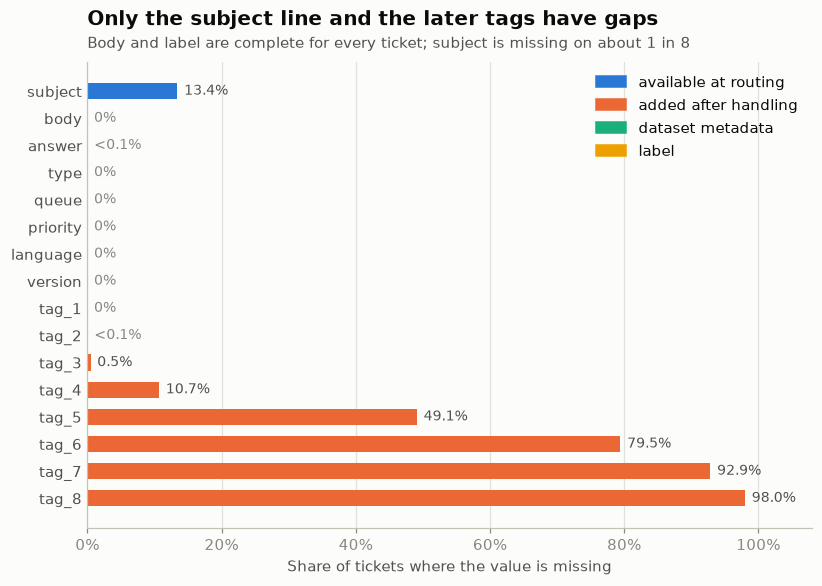

In [5]:
# Step 3 (chart 1) — missing values by column, coloured by role
missing_pct = df_raw.isna().mean().mul(100)[::-1]  # reversed so the first column sits at the top

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(missing_pct.index, missing_pct.values, height=0.6,
        color=[ROLE_COLORS[COLUMN_ROLES[c][0]] for c in missing_pct.index])
for y, v in enumerate(missing_pct.values):
    label = f"{v:.1f}%" if v >= 0.05 else ("<0.1%" if v > 0 else "0%")
    ax.text(v + 1, y, label, va="center", fontsize=9, color=INK_2 if v >= 0.05 else MUTED)

ax.set_xlim(0, 108)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Share of tickets where the value is missing")
ax.set_title("Only the subject line and the later tags have gaps", pad=24)
ax.text(0, 1.03, "Body and label are complete for every ticket; subject is missing on about 1 in 8",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.legend(handles=[Patch(color=c, label=r) for r, c in ROLE_COLORS.items()], loc="upper right")
plt.show()

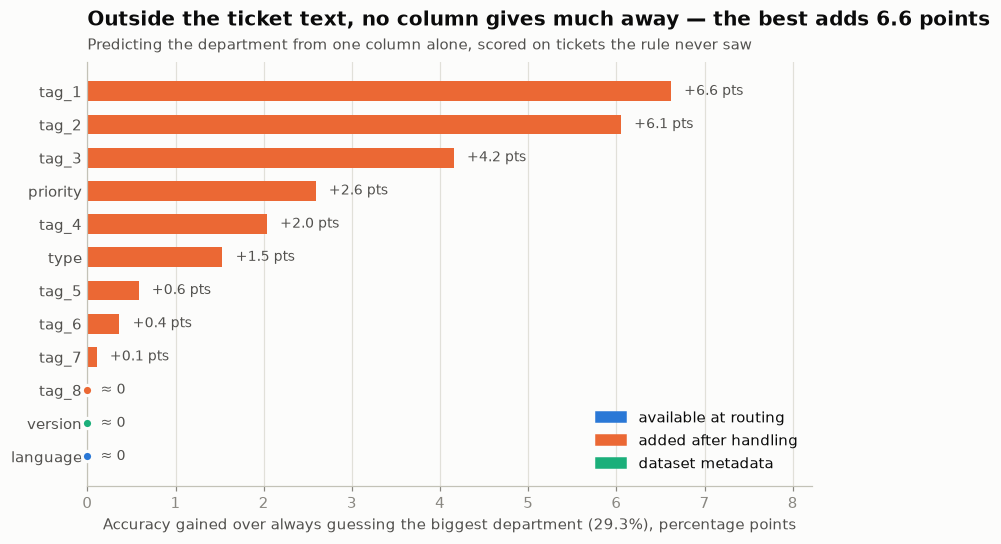

In [6]:
# Step 3 (chart 2) — how much would each non-text column give away about the department?
# Rule: predict the most common department for each value of the column. The rule is learned on one
# half of the tickets and scored on the other, so columns with hundreds of values can't just memorise.
from sklearn.model_selection import train_test_split

lookup_cols = [c for c in df_raw.columns if c not in TEXT_COLS + ["answer", LABEL]]
X_lookup = df_raw[lookup_cols].astype(str).fillna("<missing>")
X_learn, X_score, y_learn, y_score = train_test_split(
    X_lookup, df_raw[LABEL], test_size=0.5, random_state=SEED, stratify=df_raw[LABEL]
)
fallback = y_learn.mode()[0]
lookup_floor = (y_score == fallback).mean()

def lookup_accuracy(col):
    most_common_dept = y_learn.groupby(X_learn[col]).agg(lambda s: s.mode()[0])
    return (X_score[col].map(most_common_dept).fillna(fallback) == y_score).mean()

lift = pd.Series({c: lookup_accuracy(c) - lookup_floor for c in lookup_cols}).mul(100).sort_values()
lift_colors = [ROLE_COLORS[COLUMN_ROLES[c][0]] for c in lift.index]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(lift.index, lift.values, height=0.6, color=lift_colors)
for y, (v, color) in enumerate(zip(lift.values, lift_colors)):
    if v < 0.05:  # a zero-length bar is invisible, so mark it with a dot in its role colour
        ax.scatter(0, y, s=45, color=color, edgecolor=SURFACE, linewidth=2, zorder=3, clip_on=False)
    ax.text(max(v, 0) + 0.15, y, f"+{v:.1f} pts" if v >= 0.05 else "≈ 0", va="center", fontsize=9, color=INK_2)

ax.set_xlim(0, lift.max() + 1.6)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel(f"Accuracy gained over always guessing the biggest department ({lookup_floor:.1%}), percentage points")
ax.set_title(f"Outside the ticket text, no column gives much away — the best adds {lift.max():.1f} points", pad=24)
ax.text(0, 1.03, "Predicting the department from one column alone, scored on tickets the rule never saw",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
roles_shown = {COLUMN_ROLES[c][0] for c in lookup_cols}
ax.legend(handles=[Patch(color=c, label=r) for r, c in ROLE_COLORS.items() if r in roles_shown], loc="lower right")
plt.show()

In [7]:
# Step 3 (probe) — one column at a time is the weakest possible test. The fairer test: a real model
# given the excluded columns together, learned and scored on the same two halves as chart 2.
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

TAG_COLS = [f"tag_{i}" for i in range(1, 9)]

def after_handling_tokens(row, cols):
    # a tag counts the same whichever slot it sits in; type and priority keep their column name
    return [f"tag={v}" if c.startswith("tag_") else f"{c}={v}" for c, v in row[cols].dropna().items()]

probe = {}
for name, cols in [("all 8 tags together", TAG_COLS), ("tags + type + priority", TAG_COLS + ["type", "priority"])]:
    tokens = df_raw.apply(after_handling_tokens, axis=1, cols=cols)
    vec = CountVectorizer(analyzer=lambda toks: toks, binary=True)
    X_probe_learn = vec.fit_transform(tokens.loc[X_learn.index])
    pred = LogisticRegression(max_iter=2000).fit(X_probe_learn, y_learn).predict(vec.transform(tokens.loc[X_score.index]))
    acc = accuracy_score(y_score, pred)
    probe[name] = {"accuracy": acc, "gain over floor (pts)": (acc - lookup_floor) * 100,
                   "macro F1": f1_score(y_score, pred, average="macro")}

pd.DataFrame(probe).T.round(3)

,accuracy,gain over floor (pts),macro F1
all 8 tags together,0.375,8.206,0.233
tags + type + priority,0.422,12.977,0.283


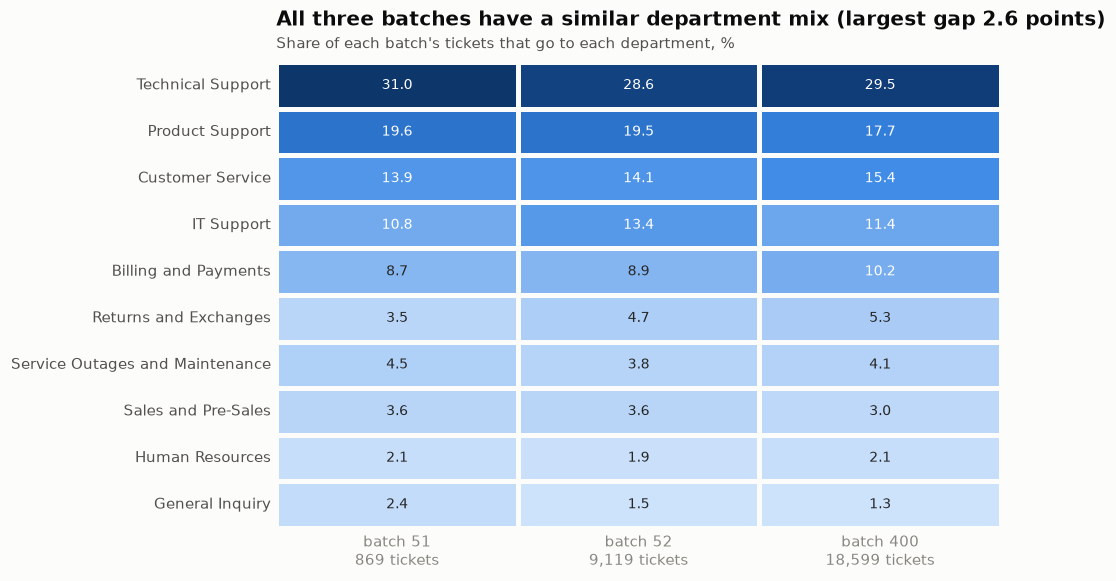

In [8]:
# Step 3 (chart 3) — does the department mix differ between the dataset's generation batches?
batch_sizes = df_raw["version"].value_counts()
batch_mix = pd.crosstab(df_raw[LABEL], df_raw["version"], normalize="columns").mul(100)
batch_mix = batch_mix.loc[df_raw[LABEL].value_counts().index]
batch_gap = (batch_mix.max(axis=1) - batch_mix.min(axis=1)).max()
batch_mix.columns = [f"batch {v}\n{batch_sizes[v]:,} tickets" for v in batch_mix.columns]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(batch_mix, annot=True, fmt=".1f", cmap=BLUES, cbar=False, linewidths=2, linecolor=SURFACE,
            annot_kws={"fontsize": 9}, ax=ax)
ax.grid(False)
ax.tick_params(length=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"All three batches have a similar department mix (largest gap {batch_gap:.1f} points)", pad=24)
ax.text(0, 1.03, "Share of each batch's tickets that go to each department, %",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()

### What Step 3 tells us

- **The model will only ever see `subject`, `body` and `language`.** Everything else is either the
  answer itself, or something a support agent adds after handling the ticket.
- **The excluded columns carry real but moderate signal.** One at a time (chart 2), the best column
  adds under 7 points of accuracy over the floor. Given to a real model *together* (the probe),
  tags + type + priority reach about 42% accuracy — roughly 13 points above the floor. They stay
  excluded regardless: the rule is about *what exists when a ticket arrives*, not about how much a
  column would help.
- **Worth noting, not yet concluding:** tags are written by someone who has read the ticket, yet
  even together they predict the department only moderately. Two explanations fit — the tags are
  generic (the same few appear across every department), or the department labels are loosely tied
  to the ticket's content. This notebook can't tell them apart yet; Step 4 takes a first look.
- **`subject` is missing on about 1 in 8 tickets** (chart 1). Those rows stay — `body` is never
  missing, so a missing subject is treated as empty text in Step 5 rather than a reason to drop the ticket.
- **The three generation batches (`version` 51, 52, 400) have a similar department mix** (chart 3,
  every department within about 3 points). The batches are unlikely to distort the splits in Step 12.

## Step 4 — Study the label (class balance)

**This is the most important early check.**

Count how many tickets each department has. If one department has 8,000 tickets and another
has 200, a model can score high accuracy by *always guessing the big one* — while being
completely useless on the small ones.

The department list at the top of this notebook comes from the dataset description. **The counts
below are the real list** — if they disagree, the data wins.

Three things to write down here:

1. **The imbalance ratio** — biggest class divided by smallest
2. **The floors** — the scores a model gets with no intelligence at all. Any real model has to
   beat these, or it's worth nothing:
   - *Always guess the biggest department* — sets the floor for **accuracy**. Its macro F1 is tiny:
     only the biggest department scores anything, the other nine score zero.
   - *Guess at random, in proportion to department sizes* — sets the floor for **macro F1**, the
     metric that guards against departments being abandoned (see Phase 3). Each department's precision and recall both
     equal its share, so its F1 equals its share — and the average over 10 departments is exactly 0.10.

   These floors describe the raw data. The floors that judge models are recomputed on the
   validation and test sets later (Steps 15 and 20), after cleaning and any language filter.
3. **Department share by language** — Step 8 filters to English only. If departments are spread
   differently across languages, that filter quietly changes the class balance. Better to know now.

Also plot the counts. A bar chart of tickets per department makes the problem obvious at a glance.

### Read before modelling

Finally, read two tickets from each department. Some departments sound alike —
*Technical Support*, *IT Support* and *Product Support* could plausibly own the same ticket.
If a human can't tell them apart from the text, a model won't either. It gives a first, rough
sense of the realistic ceiling **before** any modelling.

In [9]:
# Step 4 — value_counts on the label, imbalance ratio, accuracy floor + macro-F1 floor
class_counts = df_raw[LABEL].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"{len(class_counts)} departments | largest: {class_counts.index[0]} ({class_counts.iloc[0]:,}) | "
      f"smallest: {class_counts.index[-1]} ({class_counts.iloc[-1]:,}) | imbalance ratio {imbalance_ratio:.1f}×\n")

# Floors = scores with no intelligence, using only how common each department is (share p).
# Computed exactly from the shares — no random draw, so the numbers never wobble between runs.
p = class_counts / class_counts.sum()
floors_all_tickets = pd.DataFrame(
    {"accuracy": [p.max(), (p ** 2).sum()],
     "macro F1": [2 * p.max() / (1 + p.max()) / len(p), 1 / len(p)]},
    index=["always guess the biggest department", "guess at random, in proportion to department size"],
)
floors_all_tickets.round(3)

10 departments | largest: Technical Support (8,362) | smallest: General Inquiry (405) | imbalance ratio 20.6×



,accuracy,macro F1
always guess the biggest department,0.293,0.045
"guess at random, in proportion to department size",0.171,0.100


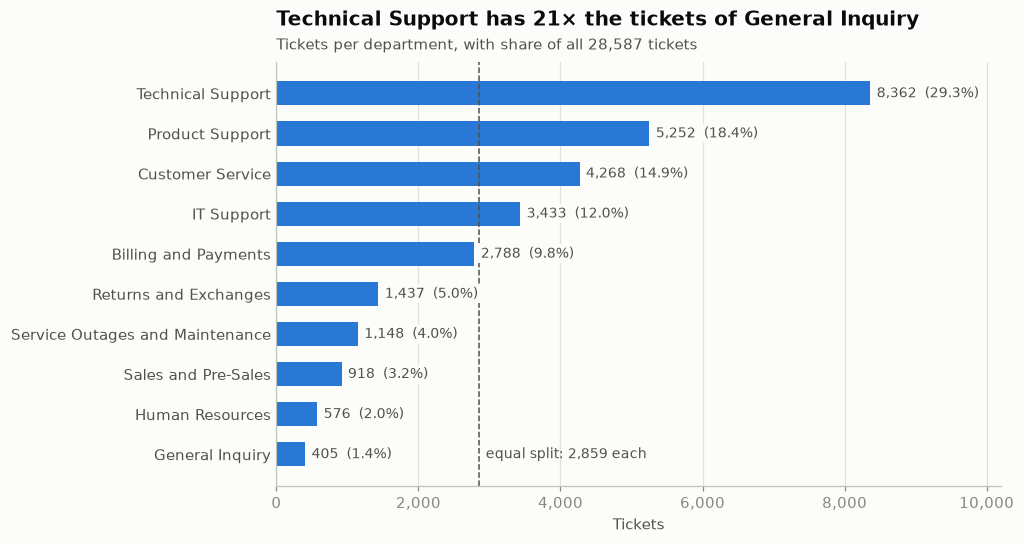

In [10]:
# Step 4 (plot) — horizontal bar chart of tickets per department
shares = class_counts / class_counts.sum()
equal_split = class_counts.sum() / len(class_counts)
label_box = dict(facecolor=SURFACE, edgecolor="none", pad=1.5)  # lets the reference line pass behind labels

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(class_counts.index[::-1], class_counts.values[::-1], height=0.6, color=CAT[0])
ax.axvline(equal_split, color=INK_2, linestyle="--", linewidth=1, zorder=1)
for y, (n, s) in enumerate(zip(class_counts.values[::-1], shares.values[::-1])):
    ax.text(n + 90, y, f"{n:,}  ({s:.1%})", va="center", fontsize=9, color=INK_2, bbox=label_box, zorder=2)
ax.text(equal_split + 90, 0, f"equal split: {equal_split:,.0f} each", va="center", fontsize=9, color=INK_2)

ax.set_xlim(0, class_counts.max() * 1.22)
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Tickets")
ax.set_title(f"{class_counts.index[0]} has {imbalance_ratio:.0f}× the tickets of {class_counts.index[-1]}", pad=24)
ax.text(0, 1.03, f"Tickets per department, with share of all {class_counts.sum():,} tickets",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()

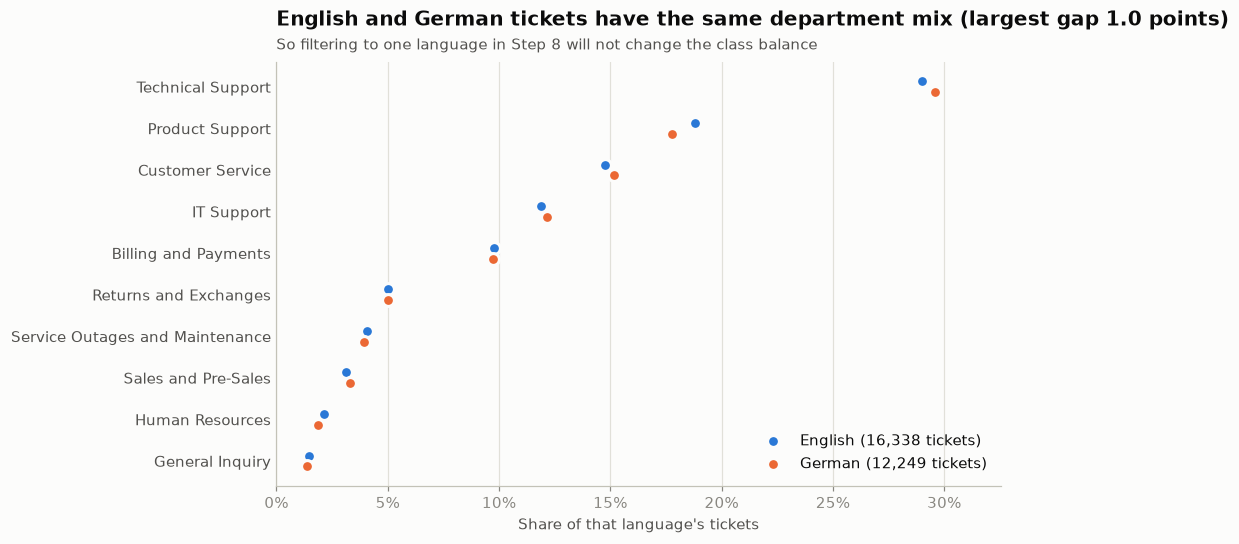

language,de,en
queue,,
Technical Support,29.6,29.0
Product Support,17.8,18.8
Customer Service,15.2,14.8
IT Support,12.2,11.9
Billing and Payments,9.7,9.8
Returns and Exchanges,5.0,5.0
Service Outages and Maintenance,4.0,4.1
Sales and Pre-Sales,3.3,3.1
Human Resources,1.9,2.1


In [11]:
# Step 4 (language) — department share by language
lang_counts = df_raw["language"].value_counts()
lang_mix = pd.crosstab(df_raw[LABEL], df_raw["language"], normalize="columns").mul(100).loc[class_counts.index[::-1]]
lang_gap = (lang_mix["en"] - lang_mix["de"]).abs().max()

fig, ax = plt.subplots(figsize=(8.5, 5))
rows = np.arange(len(lang_mix))
# English sits slightly above, German slightly below, so equal shares never hide one dot behind the other
for (code, name), color, offset in zip([("en", "English"), ("de", "German")], CAT, [0.13, -0.13]):
    ax.scatter(lang_mix[code], rows + offset, s=60, color=color, edgecolor=SURFACE, linewidth=2, zorder=3,
               label=f"{name} ({lang_counts[code]:,} tickets)")

ax.set_yticks(rows, lang_mix.index)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax.set_xlim(0, lang_mix.max().max() * 1.1)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Share of that language's tickets")
ax.set_title(f"English and German tickets have the same department mix (largest gap {lang_gap:.1f} points)", pad=24)
ax.text(0, 1.03, "So filtering to one language in Step 8 will not change the class balance",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.legend(loc="lower right")
plt.show()

lang_mix.round(1).iloc[::-1]

In [12]:
# Step 4 (read) — print 2 sample tickets per department to judge how separable they are
# English only, so any reader can judge them. The seed means everyone sees the same tickets.
SAMPLES_PER_DEPT = 2
samples = (df_raw[df_raw["language"] == "en"]
           .groupby(LABEL, group_keys=False)
           .sample(SAMPLES_PER_DEPT, random_state=SEED))

for dept in class_counts.index:
    print(f"━━ {dept} " + "━" * max(3, 60 - len(dept)))
    for _, row in samples[samples[LABEL] == dept].iterrows():
        subject = row["subject"] if pd.notna(row["subject"]) else "(no subject)"
        body = " ".join(row["body"].split())
        print(f"  ▸ {subject}\n    {body[:200]}{'…' if len(body) > 200 else ''}\n")

━━ Technical Support ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▸ Concern About Recent Decline in Digital Campaign Metrics
    We have noticed a sudden drop in the performance metrics of our digital campaign. This may be due to recent software updates or configuration changes. Despite our efforts to troubleshoot by reviewing …

  ▸ Failure in High-Intensity Projector Automation Process
    Dear Support Team,\n\nI am submitting a report regarding an issue with the automation process of our high-brightness projector system. Recently, I have experienced repeated failures in the automation …

━━ Product Support ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▸ Concerns Regarding Security of Medical Information
    Facing difficulties in securing medical information within our hospital's IT system. The problem might stem from outdated security protocols. Efforts have been made to update firewall settings and per…

  ▸ Digital Strategy Challenge
    Facing difficulties in implementing the

### What Step 4 tells us

- **The classes are imbalanced, about 21 to 1.** Technical Support has 8,362 tickets; General Inquiry
  has 405. Four departments hold 74% of all tickets.
- **The floors on the raw data:** 29.3% accuracy (always guess Technical Support) and 0.10 macro F1
  (guess at random in proportion to department size). Always guessing the biggest department scores
  only 0.05 macro F1 — which is why accuracy alone can't judge models here. Phase 3 sets out how the two metrics are used together.
- **English and German have the same department mix** (within 1 point). Filtering to one language
  in Step 8 is safe for class balance.
- **Some labels do not appear to match their ticket.** In the sample above, *Human Resources* holds a
  product integration failure and a hospital security breach; *Returns and Exchanges* holds a
  medical-data breach and an investment-forecast bug. Billing, IT Support, Service Outages and
  General Inquiry read cleanly. In this sample, roughly 12 of the 20 tickets plausibly belong to
  their department.

**How much weight this can bear:** it's 20 tickets and one reader — an early sign, not a measurement.
If it holds up, it points to **label noise** (tickets assigned to a department their text doesn't
support), and no model can be right about a label the text contradicts. The realistic ceiling
would then sit well below 100%, and a modest score would not automatically mean a weak model.

**How it gets measured properly — Step 18.** Once a model is trained, the tickets where it
*confidently* disagrees with the label, across cross-validation folds, are the prime suspects for
label noise (the idea behind *confident learning*). Reading and counting those turns this early
sign into a number. Until then, results are judged by *how far above the floors* the model gets,
and *which departments* it can and can't learn.

---
# Phase 2 — Clean the data
*Steps 5 to 10*

> **How this phase differs from a typical cleaning pass.** The data turned out clean in the usual
> ways — no duplicates, no emails or URLs, no empty tickets — and messy in an unusual one: it is built
> from **families of reworded tickets**. So this phase removes very little. Its most important output
> is a `family_id` for every ticket (Step 10), which lets the split in Step 12 keep each family on
> one side, so the model is judged on tickets it has never seen in any wording.

## Step 5 — Build the text field

The model reads one block of text per ticket. We join `subject` and `body` together into `text`.

**Why both:** the subject often carries the strongest signal ("Invoice wrong" → Billing),
while the body carries the detail that resolves ambiguous cases. When the subject is missing
(about 1 in 8 tickets, Step 3), the text is simply the body.

Also record text length (characters and words). Length isn't used to throw tickets away — Step 6
explains why — but it describes the data and lets Step 18 check how the model does on short tickets.

From here on, all work happens on `df`, a copy. `df_raw` stays untouched.

In [13]:
# Step 5 — combine subject + body into a single text column, add length columns
df = df_raw.copy()
df["text"] = (df["subject"].fillna("") + " " + df["body"].fillna("")).str.strip()
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

print(f"Tickets with no subject: {df['subject'].isna().sum():,} — their text is the body alone")
df[["n_chars", "n_words"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T.round(1)

Tickets with no subject: 3,838 — their text is the body alone


,count,mean,std,min,1%,5%,50%,95%,99%,max
n_chars,28587.0,426.7,200.8,13.0,71.0,111.0,426.0,742.0,844.0,1526.0
n_words,28587.0,58.2,27.8,1.0,9.0,14.0,59.0,97.0,110.0,180.0


## Step 6 — Drop only rows with no usable information

A row goes only if it gives the model nothing at all:

- **No label** — we can't train on it or score it
- **No text in any text column** — both `subject` and `body` are empty

**Short tickets stay.** It is tempting to drop tickets with only a few words, but a real support inbox
receives "Problems with the server" too. Removing short tickets from the test set makes the task look
easier than it is in production. Instead, Step 18 checks how the model does on short tickets specifically.

Every rule prints how many rows it removes — nothing disappears silently.

No label:                 0 rows
No text in ['subject', 'body']: 0 rows
Remaining:                28,587 of 28,587


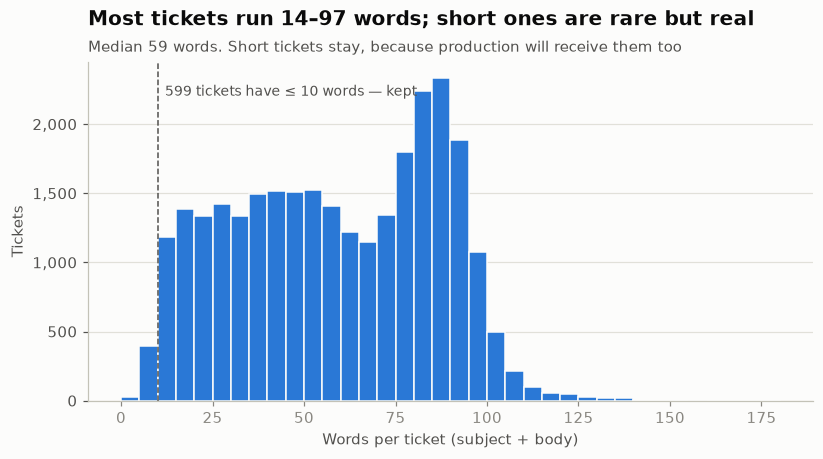

In [14]:
# Step 6 — drop only rows with no label, or no text in any text column; report counts
rows_at_start = len(df)
no_label = df[LABEL].isna()
no_text = df[TEXT_COLS].isna().all(axis=1) | (df["text"] == "")

print(f"No label:                 {no_label.sum():,} rows")
print(f"No text in {TEXT_COLS}: {no_text.sum():,} rows")
df = df[~(no_label | no_text)].copy()
print(f"Remaining:                {len(df):,} of {rows_at_start:,}")

# How short do tickets get? Shown, not filtered.
SHORT_WORDS = 10
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(df["n_words"], bins=np.arange(0, df["n_words"].max() + 5, 5), color=CAT[0], edgecolor=SURFACE, linewidth=1)
ax.axvline(SHORT_WORDS, color=INK_2, linestyle="--", linewidth=1)
ax.text(SHORT_WORDS + 2, ax.get_ylim()[1] * 0.9, f"{(df['n_words'] <= SHORT_WORDS).sum():,} tickets have "
        f"≤ {SHORT_WORDS} words — kept", fontsize=9, color=INK_2)
ax.grid(axis="x", visible=False)
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Words per ticket (subject + body)")
ax.set_ylabel("Tickets")
ax.set_title(f"Most tickets run {df['n_words'].quantile(.05):.0f}–{df['n_words'].quantile(.95):.0f} words; "
             f"short ones are rare but real", pad=24)
ax.text(0, 1.03, f"Median {df['n_words'].median():.0f} words. Short tickets stay, because production will receive them too",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()

## Step 7 — Check for exact duplicates

**Why this matters more than it sounds:** if the same ticket text appears twice, and one copy
lands in training while the other lands in test, the model has effectively been handed the
answer key. The test score goes up and means nothing.

Exact repeats of the ticket text are removed, keeping the first. The cell also checks whether any
repeated text carries *different* labels — that would be direct proof of label noise.

The check runs even if it finds nothing: "we looked, and there were none" is a result worth recording.

In [15]:
# Step 7 — find and drop exact duplicate texts; check whether any carry different labels
is_repeated = df["text"].duplicated(keep=False)
conflicting = df[is_repeated].groupby("text")[LABEL].nunique().gt(1).sum()

print(f"Extra copies of an identical text:       {df['text'].duplicated().sum():,}")
print(f"Identical texts with different labels:   {conflicting:,}")
if is_repeated.any():
    display(df.loc[is_repeated, ["text", LABEL]].sort_values("text").head(6))
df = df.drop_duplicates("text").copy()

Extra copies of an identical text:       0
Identical texts with different labels:   0


## Step 8 — Modelling language: English only

> **Decision: the model is trained and evaluated on English tickets only — 16,338 of the 28,587.**
> The 12,249 German tickets are set aside for this project, not deleted from the source data.

**Why English only:**

1. **Anyone can check the work.** Every ticket, error and example in this notebook can be read and
   judged by any reader — which matters for a result meant to be shown publicly.
2. **It removes a leak we couldn't otherwise rule out.** Step 10 finds families of reworded tickets by
   comparing their words. That works inside one language, but a German translation of an English ticket
   shares almost no words with it. If the dataset's generator translated tickets as well as rewording
   them, those pairs would slip across the train/test split undetected. One language, no blind spot.
3. **It doesn't distort the class balance.** Step 4 showed English and German have the same department
   mix, within 1 point.

**The cost, stated plainly:** this model cannot route German tickets — 43% of the dataset. A multilingual
version is a named next experiment, and it needs cross-language family detection (for example, multilingual
sentence embeddings) before it can be evaluated honestly.

In [16]:
# Step 8 — keep English tickets only (decision and reasons in the text above)
LANGUAGE = "en"
print(df["language"].value_counts().rename("tickets").to_string())
df = df[df["language"] == LANGUAGE].copy()
print(f"\nModelling set: {len(df):,} tickets in '{LANGUAGE}'")

language
en    16338
de    12249

Modelling set: 16,338 tickets in 'en'


## Step 9 — Light text cleaning

**Common mistake: over-cleaning.** Aggressive stemming and stopword removal often *hurt* text models
because they throw away real signal. So there is no stemming and no stopword removal here — TF-IDF
already down-weights words that appear everywhere.

What *does* need removing is **formatting left over from how the tickets were stored**:

- a literal `\n` (a backslash followed by "n", not a real line break) in about 4% of tickets
- HTML line breaks, `<br>`, over 2,000 of them

These are not words, and a stopword list can't catch them: when text is split into words, `\n\nThank`
becomes the fake word `nthank` and `<br>` becomes `br`. They have to be replaced with a space *before*
the text is split into words.

**Kept as they are:** placeholders the dataset already uses for personal details — `<tel_num>`,
`<acc_num>`, `<name>`, `<email>`. A production system would anonymise the same way, and "the customer
included an account number" is legitimate signal.

**Safety net:** emails, URLs and long numbers would be replaced with placeholders too. They barely
occur in this dataset, but the rules stay in, with counts printed, so the cleaning holds up on new data.

In [17]:
# Step 9 — replace formatting leftovers with spaces, apply safety-net placeholders, show before/after
FORMATTING = r"\\n|<br\s*/?>"   # a literal backslash-n, and HTML line breaks
SAFETY_NET = {
    "email address": (r"[\w.+-]+@[\w-]+\.[\w.]+", " <email> "),
    "URL":           (r"https?://\S+|www\.\S+", " <url> "),
    "long number":   (r"\b\d{5,}\b", " <num> "),
}

has_formatting = df["text"].str.contains(FORMATTING, regex=True)
example_idx = df.index[has_formatting][0]
before = df.at[example_idx, "text"]

print(f"{'formatting leftovers':22s} in {has_formatting.sum():,} tickets → replaced with a space")
df["text"] = df["text"].str.replace(FORMATTING, " ", regex=True)
for name, (pattern, placeholder) in SAFETY_NET.items():
    print(f"{name:22s} in {df['text'].str.contains(pattern, regex=True).sum():,} tickets → {placeholder.strip()}")
    df["text"] = df["text"].str.replace(pattern, placeholder, regex=True)

df["text"] = df["text"].str.split().str.join(" ")   # collapse the spaces left behind
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

placeholders = df["text"].str.findall(r"<[a-z_]+>").explode().value_counts()
print(f"\nPlaceholders now in the text (dataset's own + safety net): {placeholders.to_dict()}")
print(f"\nBEFORE: {before[:230]}…\nAFTER:  {df.at[example_idx, 'text'][:230]}…")

formatting leftovers   in 1,082 tickets → replaced with a space

email address          in 0 tickets → <email>


URL                    in 0 tickets → <url>
long number            in 14 tickets → <num>



Placeholders now in the text (dataset's own + safety net): {'<tel_num>': 180, '<acc_num>': 39, '<num>': 14, '<name>': 8, '<email>': 2}

BEFORE: Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settin…
AFTER:  Account Disruption Dear Customer Support Team, I am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings,…


## Step 10 — Find families of reworded tickets

The dataset is synthetic, and it shows: many tickets are rewordings of the same original —
*"Query Regarding Integration Resources"* next to *"Questions About Integration Resources"* — and
the members of a family almost always share one department.

**Why this matters:** a random split scatters family members across train and test. The model then
earns points by recognising a sibling it has already seen, not by understanding what makes a ticket
belong to a department. An exploratory check put the inflation at roughly ten accuracy points;
Step 16 measures it properly.

**The fix is not to delete them** — that would throw away about half the data, including real variety in
how people phrase things. Instead, every ticket gets a `family_id`, and Step 12 splits whole families,
so each family lands entirely in train, validation or test.

**How families are found:** each ticket is turned into word weights (TF-IDF), and every pair of tickets
gets a similarity score from 0 (no shared words) to 1 (identical). Pairs at or above a threshold are
linked; everything connected through links forms one family.

**Choosing the threshold from evidence, not by feel.** The chart below shows, for each similarity level,
how often a ticket's closest neighbour has the *same department*. Loosely related tickets agree about a
third of the time. Family members agree almost always. Agreement stays far above the loosely-related rate
down to a similarity of about **0.6**. Below 0.55, unrelated tickets start chaining into one giant group.
So the threshold is **0.60**.

> **Is computing similarity on all English tickets a leak?** No. The word weights here only decide which
> tickets travel together into the split — they never reach the model. Step 13 fits a fresh vectoriser on
> the training set alone.

In [18]:
# Step 10 — link tickets whose similarity is >= FAMILY_THRESHOLD; each connected group is one family
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import TfidfVectorizer

FAMILY_THRESHOLD = 0.60
df = df.reset_index(drop=True)
X_sim = TfidfVectorizer(sublinear_tf=True, min_df=2).fit_transform(df["text"])
n = X_sim.shape[0]

nearest_sim, nearest_idx = np.zeros(n), np.zeros(n, dtype=int)
edge_rows, edge_cols = [], []
for start in range(0, n, 1000):  # in blocks, so the full n × n similarity matrix never sits in memory
    block = (X_sim[start:start + 1000] @ X_sim.T).toarray()
    rows = np.arange(block.shape[0])
    block[rows, start + rows] = 0  # a ticket is not its own neighbour
    nearest_sim[start + rows] = block.max(axis=1)
    nearest_idx[start + rows] = block.argmax(axis=1)
    r, c = np.nonzero(block >= FAMILY_THRESHOLD)
    edge_rows.append(r + start)
    edge_cols.append(c)

links = coo_matrix((np.ones(sum(map(len, edge_rows))), (np.concatenate(edge_rows), np.concatenate(edge_cols))), shape=(n, n))
n_families, family_id = connected_components(links, directed=False)
df["family_id"] = family_id

family_size = df["family_id"].map(df["family_id"].value_counts())
print(f"{n:,} tickets → {n_families:,} families")
print(f"  tickets with at least one reworded sibling: {(family_size > 1).sum():,} ({(family_size > 1).mean():.0%})")
print(f"  tickets with no sibling:                    {(family_size == 1).sum():,}")
print(f"  largest family:                             {family_size.max():,} tickets ({family_size.max() / n:.1%})")

16,338 tickets → 7,985 families
  tickets with at least one reworded sibling: 12,618 (77%)
  tickets with no sibling:                    3,720
  largest family:                             285 tickets (1.7%)


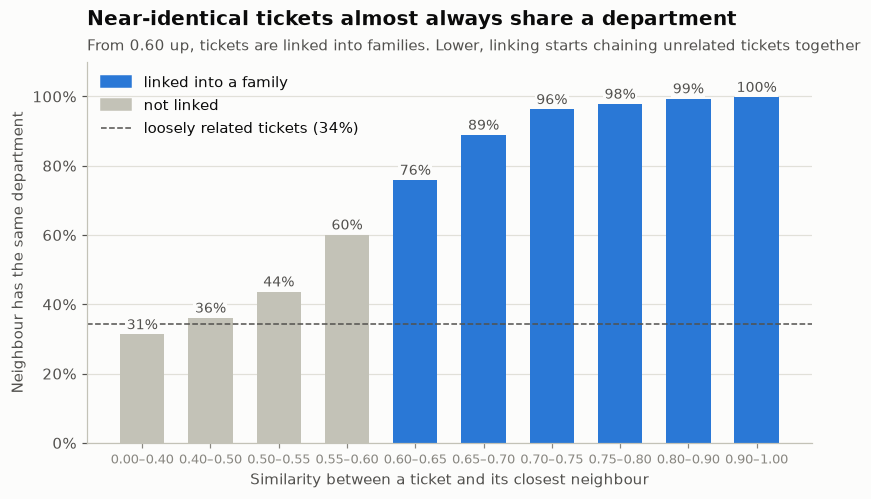

,tickets,same department
"[0.0, 0.4)",929,0.313
"[0.4, 0.5)",1507,0.361
"[0.5, 0.55)",655,0.437
"[0.55, 0.6)",629,0.601
"[0.6, 0.65)",705,0.759
"[0.65, 0.7)",1036,0.889
"[0.7, 0.75)",1424,0.963
"[0.75, 0.8)",1849,0.978
"[0.8, 0.9)",4900,0.994
"[0.9, 1.0)",2704,0.998


In [19]:
# Step 10 (chart) — the evidence for the threshold: how often a ticket's closest neighbour shares its department
from matplotlib.lines import Line2D

labels = df[LABEL].to_numpy()
same_dept = labels == labels[nearest_idx]
band_edges = [0, 0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9, 1.0001]
bands = pd.cut(nearest_sim, band_edges, right=False)
agreement = pd.DataFrame({
    "tickets": pd.Series(bands).value_counts(sort=False),
    "same department": pd.Series(same_dept).groupby(bands, observed=False).mean(),
})
loose_rate = same_dept[nearest_sim < 0.5].mean()
in_family = [iv.left >= FAMILY_THRESHOLD for iv in agreement.index]
band_names = [f"{iv.left:.2f}–{min(iv.right, 1):.2f}" for iv in agreement.index]
label_box = dict(facecolor=SURFACE, edgecolor="none", pad=1)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(agreement))
ax.bar(x, agreement["same department"] * 100, width=0.65, color=[CAT[0] if f else AXIS for f in in_family])
ax.axhline(loose_rate * 100, color=INK_2, linestyle="--", linewidth=1, zorder=1)
for xi, v in zip(x, agreement["same department"] * 100):
    ax.text(xi, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9, color=INK_2, bbox=label_box, zorder=3)

ax.set_xticks(x, band_names, fontsize=8.5)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.grid(axis="x", visible=False)
ax.set_xlabel("Similarity between a ticket and its closest neighbour")
ax.set_ylabel("Neighbour has the same department")
ax.set_title("Near-identical tickets almost always share a department", pad=24)
ax.text(0, 1.03, f"From {FAMILY_THRESHOLD:.2f} up, tickets are linked into families. Lower, linking starts chaining unrelated tickets together",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.legend(handles=[Patch(color=CAT[0], label="linked into a family"), Patch(color=AXIS, label="not linked"),
                   Line2D([0], [0], color=INK_2, linestyle="--", linewidth=1, label=f"loosely related tickets ({loose_rate:.0%})")],
          loc="upper left")
plt.show()

agreement.assign(**{"same department": agreement["same department"].round(3)})

In [20]:
# Step 10 (read) — what a pair right at the threshold looks like: are these really the same ticket reworded?
at_threshold = np.where((nearest_sim >= FAMILY_THRESHOLD) & (nearest_sim < FAMILY_THRESHOLD + 0.05))[0]
for i in np.random.default_rng(SEED).choice(at_threshold, size=3, replace=False):
    j = nearest_idx[i]
    print(f"similarity {nearest_sim[i]:.2f}")
    print(f"  ▸ [{labels[i]}] {df.at[i, 'text'][:150]}…")
    print(f"  ▸ [{labels[j]}] {df.at[j, 'text'][:150]}…\n")

similarity 0.65
  ▸ [IT Support] Concerns with Investment Analytics Dashboard Hello Customer Support, I am encountering difficulties with the investment analytics dashboard while prep…
  ▸ [Technical Support] Hello customer support, I am encountering an issue with the analytics dashboard report for investment performance metrics. The displayed data seems to…

similarity 0.64
  ▸ [Customer Service] Could you provide details on how digital strategies can effectively promote brand growth in companies? I am eager to understand the approach and the r…
  ▸ [Customer Service] Could you share information on how digital strategies can effectively promote brand development within organizations? I am eager to understand the met…

similarity 0.65
  ▸ [Returns and Exchanges] Problem with Project Management Tool Access We are encountering sporadic issues with the project management tool that are affecting user access. Recen…
  ▸ [Returns and Exchanges] Problem with Project Management Tool Login We a

### What Phase 2 tells us

| Step | Rule | Tickets out | Tickets left |
|---|---|---|---|
| 5 | Build `text` from subject + body | 0 | 28,587 |
| 6 | No label, or no text in any text column | 0 | 28,587 |
| 7 | Exact duplicate text | 0 | 28,587 |
| 8 | English only (German set aside) | 12,249 | **16,338** |
| 9 | Formatting leftovers replaced in 1,082 tickets; 14 long numbers masked | 0 | 16,338 |
| 10 | Families recorded as `family_id` | 0 | 16,338 |

- **Conventional cleaning had almost nothing to do.** No missing labels, no empty tickets, no exact
  duplicates, no emails or URLs. The only row loss is the deliberate language choice.
- **The real structure is families.** 77% of English tickets belong to a family of rewordings; the
  16,338 tickets collapse into 7,985 families, the largest holding 285 tickets (1.7%) — no runaway chain.
- **The threshold is backed by evidence, not chosen by feel.** At similarity ≥ 0.60, a ticket's closest
  neighbour shares its department 76–100% of the time, against 34% for loosely related tickets.
- **A first concrete case of labels disagreeing on near-identical text.** One of the threshold pairs above
  describes the same investment-dashboard problem but is labelled *IT Support* in one wording and
  *Technical Support* in the other. The model cannot win on both — a small, direct piece of the label-noise
  question that Step 18 measures properly.
- **Ticket length is bimodal** (Step 6 chart): short direct messages around 15–60 words, and longer
  "Dear Customer Support Team…" letters around 80–95 words — two writing templates in the generator.

**What carries forward:** `df` (16,338 English tickets, cleaned `text`, `family_id`). Step 12 splits whole
families; tuning (Step 17) and the label-noise check (Step 18) use cross-validation grouped by family too.

---
# Phase 3 — Prepare for modelling
*Steps 11 to 14*

> **How models are judged in this project — decided before any model is trained.**
>
> - **Accuracy picks the winner.** The job is to put each ticket in front of the right department, so the
>   share of tickets routed correctly is what matters most.
> - **Macro F1 is the guardrail.** A model is only allowed to win if it does not abandon any department:
>   every department must have **recall above zero** — the model must route at least some of its tickets
>   correctly. A model that never sends anything to Human Resources is broken, however good its accuracy.
> - **Both are always reported side by side**, each against its own floor, recomputed on the data being scored.
>
> Deciding this now, before seeing any results, stops the metric being chosen afterwards to flatter
> whichever model happened to do well.

## Step 11 — Check for very rare departments

If a department has only a handful of tickets, we can't train on it *or* score it honestly — a split
needs several examples of every department in every piece.

The rule: departments with fewer than **30** tickets would be merged into an `Other` bucket rather than
dropped (dropping would pretend those tickets don't exist, and surprise someone in production).

In the English modelling set the smallest department, General Inquiry, still has over 200 tickets, so
**no department is merged — all 10 are kept.** The check stays in so the notebook would catch it if the
data changed.

In [21]:
# Step 11 — merge departments below MIN_CLASS_SIZE into 'Other' (none expected), show final distribution
MIN_CLASS_SIZE = 30
dept_counts = df[LABEL].value_counts()
rare = dept_counts[dept_counts < MIN_CLASS_SIZE]
print(f"Departments below {MIN_CLASS_SIZE} tickets: {list(rare.index) or 'none'}")
df[LABEL] = df[LABEL].where(~df[LABEL].isin(rare.index), "Other")

dept_counts = df[LABEL].value_counts()
print(f"{len(dept_counts)} departments | imbalance ratio {dept_counts.max() / dept_counts.min():.1f}×\n")
dept_counts.to_frame("tickets").assign(share=lambda t: (t["tickets"] / t["tickets"].sum()).round(3))

Departments below 30 tickets: none
10 departments | imbalance ratio 20.1×



,tickets,share
queue,,
Technical Support,4737,0.290
Product Support,3073,0.188
Customer Service,2410,0.148
IT Support,1942,0.119
Billing and Payments,1595,0.098
Returns and Exchanges,820,0.050
Service Outages and Maintenance,664,0.041
Sales and Pre-Sales,513,0.031
Human Resources,348,0.021


## Step 12 — Split into train / validation / test, keeping families whole

Three separate pieces, each with a distinct job:

| Split | Share | Job |
|---|---|---|
| **Train** | ~71% | The model learns from this |
| **Validation** | ~14% | Compare models, check settings |
| **Test** | ~14% | Locked away — opened exactly once, at Step 20 |

**Grouped by family (Step 10).** Every family of reworded tickets goes entirely into one split. Without
this, the model would be tested on rewordings of tickets it trained on, and the score would reward
recognition instead of understanding.

**Stratified at the same time** — each department keeps the same share in all three splits.
`StratifiedGroupKFold` does both: it divides families into 7 equal folds with matching department mix.
One fold becomes the test set; the remaining six are divided again, one of those becoming validation.
That is why the shares land at 71.4 / 14.3 / 14.3 rather than a round 70 / 15 / 15 — a trade worth making
for exact family separation, using only standard library tools.

**Families with mixed labels keep their labels.** A few families contain the same ticket reworded but
filed under different departments. Relabelling or dropping them *before* evaluation would make the test
set cleaner than real data and inflate the score — so they stay as they are, and Step 18 examines them.

**Critical ordering:** the split happens *before* any balancing or vectorizing. Doing it the
other way round leaks information from test into training and inflates the final number.

Verified afterwards: **no family appears in more than one split** (an `assert` stops the notebook if it
ever does), and department shares match across the three splits.

In [22]:
# Step 12 — family-grouped, stratified train / validation / test split; verify
from sklearn.model_selection import StratifiedGroupKFold

y_all, groups = df[LABEL].to_numpy(), df["family_id"].to_numpy()
all_idx = np.arange(len(df))

# 1 fold of 7 (~14.3%) → test; then 1 fold of 6 of the remainder (~14.3% of all) → validation
rest_idx, test_idx = next(StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED).split(all_idx, y_all, groups))
tr, va = next(StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED).split(rest_idx, y_all[rest_idx], groups[rest_idx]))
train_df, val_df, test_df = df.iloc[rest_idx[tr]], df.iloc[rest_idx[va]], df.iloc[test_idx]

splits = {"train": train_df, "validation": val_df, "test": test_df}
for (a, da), (b, db) in [(("train", train_df), ("validation", val_df)), (("train", train_df), ("test", test_df)),
                         (("validation", val_df), ("test", test_df))]:
    assert not set(da["family_id"]) & set(db["family_id"]), f"a family appears in both {a} and {b}"
print("No family crosses splits ✓")

mixed_families = df.groupby("family_id")[LABEL].nunique().gt(1)
print(f"Families holding more than one department: {mixed_families.sum():,} "
      f"({df['family_id'].map(mixed_families).sum():,} tickets) — kept as labelled\n")

split_summary = pd.DataFrame({name: s[LABEL].value_counts(normalize=True).mul(100) for name, s in splits.items()})
split_summary.loc["— tickets —"] = [len(s) for s in splits.values()]
split_summary.loc["— share of all —"] = [len(s) / len(df) * 100 for s in splits.values()]
gap = (split_summary.iloc[:-2].max(axis=1) - split_summary.iloc[:-2].min(axis=1)).max()
print(f"Largest difference in any department's share across splits: {gap:.2f} points")
split_summary.round(1)

No family crosses splits ✓
Families holding more than one department: 177 (1,788 tickets) — kept as labelled

Largest difference in any department's share across splits: 0.04 points


,train,validation,test
queue,,,
Technical Support,29.0,29.0,29.0
Product Support,18.8,18.8,18.8
Customer Service,14.7,14.7,14.8
IT Support,11.9,11.9,11.9
Billing and Payments,9.8,9.8,9.8
Returns and Exchanges,5.0,5.0,5.0
Service Outages and Maintenance,4.1,4.1,4.1
Sales and Pre-Sales,3.1,3.2,3.1
Human Resources,2.1,2.1,2.1


## Step 13 — Turn text into numbers (TF-IDF)

Models need numbers, not words. TF-IDF scores each word by how often it appears in a ticket,
divided by how common it is across all tickets — so "invoice" counts for a lot and "the"
counts for almost nothing.

**Settings used for the baseline:**

- **`ngram_range=(1,2)`** — single words and word pairs, so "payment failed" is a feature, not
  just "payment" and "failed" separately
- **`min_df=2`** — ignore words appearing in only one ticket (usually typos)
- **`max_df=0.9`** — ignore words appearing in 90%+ of tickets (no discriminating power)
- **`sublinear_tf=True`** — dampen the effect of a word repeated many times in one ticket

Character chunks (3–5 letters, more robust to rewording and typos) are tried as an alternative in
Step 17 — they are only kept if they win there.

**The rule again:** `fit` on training data only. Validation and test get `transform` only.

> **One more rule for cross-validation (Steps 16–18).** There, the vectorizer lives inside a scikit-learn
> `Pipeline`, so each fold learns its vocabulary from its own training part. Fitting it once on all of
> train and then cross-validating would quietly leak vocabulary between folds.

As a sanity check, the second cell lists the words that most set each department apart in the training
set. Clear, sensible words suggest learnable departments; generic ones foreshadow trouble.

In [23]:
# Step 13 — fit TfidfVectorizer on train, transform val and test
TFIDF_PARAMS = dict(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)

vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])
y_train, y_val, y_test = train_df[LABEL], val_df[LABEL], test_df[LABEL]

print(f"Vocabulary learned from train: {len(vectorizer.vocabulary_):,} words and word pairs")
for name, X in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"  {name:10s} {X.shape[0]:>6,} tickets × {X.shape[1]:,} features")

Vocabulary learned from train: 43,220 words and word pairs
  train      11,670 tickets × 43,220 features
  validation  2,334 tickets × 43,220 features
  test        2,334 tickets × 43,220 features


In [24]:
# Step 13 (read) — the words that most set each department apart, learned from train only
terms = vectorizer.get_feature_names_out()
distinctive = {}
for dept in y_train.value_counts().index:
    in_dept = (y_train == dept).to_numpy()
    lift = np.asarray(X_train[in_dept].mean(axis=0)).ravel() - np.asarray(X_train[~in_dept].mean(axis=0)).ravel()
    distinctive[dept] = ", ".join(terms[np.argsort(lift)[::-1][:8]])
pd.Series(distinctive, name="most distinctive words and word pairs").to_frame()

,most distinctive words and word pairs
Technical Support,"issue, software, the issue, problem, restarting, issues, breach, the problem"
Product Support,"engagement, targeting, not, brand, campaign, campaigns, results, efforts to"
Customer Service,"on, integrating, details, you, strategies, details on, could you, management"
IT Support,"server, network, tools, devices, system, digital tools, connectivity, restarting"
Billing and Payments,"billing, payment, the billing, subscription, you, options, services, details"
Returns and Exchanges,"returns, investment returns, investment, return, engagement, product, in investment, brand engagement"
Service Outages and Maintenance,"service, outage, outages, disruption, service outage, impacting, disruptions, network"
Sales and Pre-Sales,"solutions, information on, sales, saas, about, features, integration, details"
Human Resources,"employee, investment optimization, access, hospital systems, hr, employees, optimization, provide details"
General Inquiry,"engagement, improve, audience, our, enhance, smart home, results, home"


## Step 14 — Deal with class imbalance

From Step 4 we know some departments are much bigger than others — about 20 to 1 in the English set.

**Option 1 — Class weights.** Tell the model that getting a small department wrong costs more.
No data is duplicated or discarded.

**Option 2 — Resampling.** Duplicate small-department rows or delete big-department rows.
Risks overfitting on duplicated rows, or throwing away real information. Not used here.

**Class weights are not assumed — the data decides.** Weighting ("balanced") usually helps small
departments but costs some overall accuracy, and accuracy picks the winner in this project. So both
options — no weights, and balanced weights — go into the grouped cross-validation search in Step 17,
and the rule from Phase 3 chooses.

The weights below are computed from the **training set only**, so it's visible how strongly small
departments would be boosted if balancing wins.

In [25]:
# Step 14 — compute balanced class weights from train, display them against department size
from sklearn.utils.class_weight import compute_class_weight

departments = np.sort(y_train.unique())
balanced = compute_class_weight("balanced", classes=departments, y=y_train)
pd.DataFrame({"train tickets": y_train.value_counts().reindex(departments),
              "weight if balanced": balanced.round(2)}).sort_values("train tickets", ascending=False)

,train tickets,weight if balanced
queue,,
Technical Support,3383,0.34
Product Support,2195,0.53
Customer Service,1721,0.68
IT Support,1387,0.84
Billing and Payments,1139,1.02
Returns and Exchanges,586,1.99
Service Outages and Maintenance,474,2.46
Sales and Pre-Sales,366,3.19
Human Resources,249,4.69


### What Phase 3 tells us

- **All 10 departments are kept.** The smallest English department, General Inquiry, has 236 tickets —
  no merging needed. Imbalance is about 20 to 1.
- **The split is clean.** 11,670 / 2,334 / 2,334 tickets (71.4 / 14.3 / 14.3%). No family appears in more
  than one split, and every department's share matches across splits to within 0.04 points.
- **177 families (1,788 tickets) hold more than one department** — the same ticket, reworded, filed in
  different places. They keep their labels; Step 18 examines them.
- **The distinctive-words table is revealing.** IT Support (server, network, connectivity), Billing
  (billing, payment, subscription) and Service Outages (outage, disruption) are coherent. Others are not:
  **Returns and Exchanges is driven by "investment returns"** — the word *return* in a financial sense, not
  product returns — and Human Resources mixes real HR words (employee, hr) with *investment optimization*
  and *hospital systems*. This suggests some departments were assigned by surface keywords when the dataset
  was generated. It explains the investment-forecast ticket filed under Returns in Step 4, and it is the
  clearest sign yet of where the model will struggle.
- **If class weights win in Step 17,** General Inquiry tickets would count about 7× a normal ticket and
  Technical Support about a third — a strong push towards small departments, at some cost to accuracy.

**What carries forward:** `train_df` / `val_df` / `test_df`, the fitted `vectorizer` with `X_train` /
`X_val` / `X_test`, and `TFIDF_PARAMS` for rebuilding the same features inside cross-validation pipelines.

---
# Phase 4 — Baseline models
*Steps 15 to 16*

## Step 15 — Train the baseline models

**Always establish a floor before reaching for anything complicated.** If a simple model gets
you 90% of the way, an expensive model needs to justify itself.

Every model reads the same input — the TF-IDF word weights from Step 13 — and outputs one department.

| Model | How it decides, in plain words | Strong point | Weak point |
|---|---|---|---|
| **Dummy — always biggest** | Ignores the text; always says Technical Support | Sets the **accuracy floor** | Not a real model |
| **Dummy — random by size** | Ignores the text; guesses in proportion to department size | Sets the **macro-F1 floor** | Not a real model |
| **Logistic Regression** | Gives every word a weight per department, adds them up, picks the highest total | Fast, readable word weights, gives probabilities | Sees words one at a time, not their order |
| **Linear SVM** | Also word weights, but tuned to leave the widest possible gap between departments | Often the best on text | No reliable probabilities |
| **Complement Naive Bayes** | Checks how typical each word is of the *other* departments, picks the best fit | Very fast, built for unequal department sizes | Very simple view of words |
| **Random Forest** | 300 decision trees ("if the ticket says *billing*…") that vote | Can find word combinations | Usually weaker on text with many words |

**"(balanced)"** means mistakes on small departments cost more during training, so the model picks small
departments more often. Every model that supports it is trained both ways.

### How they are scored: grouped cross-validation on the training set

The validation set holds only 33 General Inquiry tickets — one or two tickets would decide whether a model
"abandons" that department. So models are scored with **5-fold cross-validation on the training set, folds
grouped by family**: the training tickets are cut into 5 parts, each part is predicted by a model trained on
the other 4, and every training ticket gets one honest prediction. That is five times more tickets to judge
by (170 General Inquiry instead of 33), with the same rule that no family is split. The validation set is
then used once, to **confirm** the chosen model. The test set stays sealed.

For each model: accuracy, macro F1, weighted F1, and **every department's recall** — the guardrail.

In [26]:
# Step 15 — score every model with 5-fold cross-validation on the training set, folds grouped by family
import time
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_predict
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

candidates = {
    "Dummy — always biggest": DummyClassifier(strategy="most_frequent"),
    "Dummy — random by size": DummyClassifier(strategy="stratified", random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Logistic Regression (balanced)": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Linear SVM": LinearSVC(),
    "Linear SVM (balanced)": LinearSVC(class_weight="balanced"),
    "Complement Naive Bayes": ComplementNB(),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "Random Forest (balanced)": RandomForestClassifier(n_estimators=300, random_state=SEED, class_weight="balanced"),
}
GROUPED_CV = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluate(y_true, y_pred, labels=None):
    labels = departments if labels is None else labels
    recalls = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "lowest department recall": recalls.min(),
        "weakest department": labels[recalls.argmin()],
    }
    return metrics, recalls

cv_rows, cv_recalls, cv_preds = {}, {}, {}
for name, model in candidates.items():
    start = time.perf_counter()
    pipeline = make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), clone(model))  # vocabulary refit inside every fold
    pred = cross_val_predict(pipeline, train_df["text"], y_train, groups=train_df["family_id"], cv=GROUPED_CV, n_jobs=-1)
    metrics, recalls = evaluate(y_train, pred)
    cv_rows[name] = {**metrics, "seconds": time.perf_counter() - start}
    cv_recalls[name], cv_preds[name] = recalls, pred

cv_results = pd.DataFrame(cv_rows).T.astype({"accuracy": float, "macro F1": float, "weighted F1": float,
                                             "lowest department recall": float, "seconds": float})
cv_results["passes guardrail"] = cv_results["lowest department recall"] > 0
recall_table = pd.DataFrame(cv_recalls, index=departments).T
cv_results.sort_values("accuracy", ascending=False).round(3)

,accuracy,macro F1,weighted F1,lowest department recall,weakest department,seconds,passes guardrail
Random Forest,0.388,0.222,0.323,0.000,General Inquiry,29.072,False
Random Forest (balanced),0.384,0.287,0.359,0.006,General Inquiry,34.698,True
Complement Naive Bayes,0.384,0.247,0.342,0.006,General Inquiry,1.168,True
Logistic Regression,0.383,0.242,0.341,0.000,General Inquiry,7.183,False
Linear SVM,0.363,0.284,0.348,0.012,General Inquiry,2.237,True
Linear SVM (balanced),0.347,0.294,0.343,0.071,General Inquiry,2.466,True
Logistic Regression (balanced),0.345,0.297,0.345,0.071,General Inquiry,4.707,True
Dummy — always biggest,0.290,0.045,0.130,0.000,Billing and Payments,2.319,False
Dummy — random by size,0.167,0.101,0.166,0.018,General Inquiry,1.830,True


## Step 16 — Compare the baselines and pick one

**The selection rule, fixed in Phase 3 and made precise here:**

1. **Guardrail first.** A model qualifies only if **every department has recall above zero** in
   cross-validation — it routes at least some of each department's tickets correctly.
2. **Accuracy decides among qualifiers.** But differences under **1 point** are within measurement noise,
   so models within 1 point of the best accuracy count as **tied**.
3. **Ties are broken by macro F1, then by whether the model gives probabilities** — Step 19's plan to
   auto-route only confident tickets needs them.
4. **If no model qualifies, the notebook says so plainly.** The rule is not relaxed after seeing results.

The cells below show: the comparison, every model's recall per department (the guardrail, made visible),
where the General Inquiry tickets actually go, a confirmation on the validation set, and how much a
standard random split would have overstated the result.

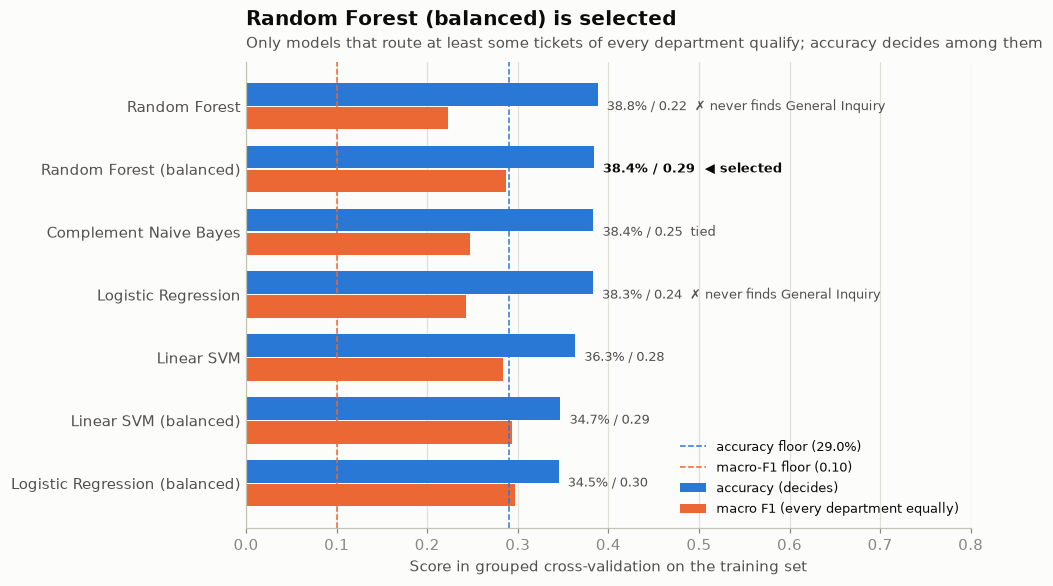

Selected: Random Forest (balanced)


,accuracy,macro F1,weighted F1,lowest department recall,weakest department,seconds,passes guardrail,gives probabilities
Complement Naive Bayes,0.384,0.247,0.342,0.006,General Inquiry,1.168,True,True
Random Forest (balanced),0.384,0.287,0.359,0.006,General Inquiry,34.698,True,True


In [27]:
# Step 16 — accuracy vs macro F1 per model (cross-validation), floors marked, selection rule applied
TIE_TOLERANCE = 0.01
CV_FLOOR_ACCURACY = cv_results.loc["Dummy — always biggest", "accuracy"]
CV_FLOOR_MACRO_F1 = cv_results.loc["Dummy — random by size", "macro F1"]
models_only = cv_results[~cv_results.index.str.startswith("Dummy")]
qualifying = models_only[models_only["passes guardrail"]]

tied = pd.DataFrame()
if qualifying.empty:
    BEST_BASELINE = None
    print("No model passes the guardrail: every model has at least one department it never routes correctly.")
else:
    tied = qualifying[qualifying["accuracy"] >= qualifying["accuracy"].max() - TIE_TOLERANCE].copy()
    tied["gives probabilities"] = [hasattr(candidates[n], "predict_proba") for n in tied.index]
    BEST_BASELINE = tied.sort_values(["macro F1", "gives probabilities"], ascending=False).index[0]

plot_df = models_only.sort_values("accuracy")
fig, ax = plt.subplots(figsize=(8.5, 5.5))
y = np.arange(len(plot_df))
ax.barh(y + 0.19, plot_df["accuracy"], height=0.36, color=CAT[0], label="accuracy (decides)")
ax.barh(y - 0.19, plot_df["macro F1"], height=0.36, color=CAT[1], label="macro F1 (every department equally)")
ax.axvline(CV_FLOOR_ACCURACY, color=CAT[0], linestyle="--", linewidth=1, label=f"accuracy floor ({CV_FLOOR_ACCURACY:.1%})")
ax.axvline(CV_FLOOR_MACRO_F1, color=CAT[1], linestyle="--", linewidth=1, label=f"macro-F1 floor ({CV_FLOOR_MACRO_F1:.2f})")
for yi, (name, r) in zip(y, plot_df.iterrows()):
    if name == BEST_BASELINE:
        note = "  ◀ selected"
    elif not r["passes guardrail"]:
        note = f"  ✗ never finds {r['weakest department']}"
    elif name in tied.index:
        note = "  tied"
    else:
        note = ""
    ax.text(max(r["accuracy"], r["macro F1"]) + 0.01, yi, f"{r['accuracy']:.1%} / {r['macro F1']:.2f}{note}", va="center",
            fontsize=8.5, color=INK if name == BEST_BASELINE else INK_2, fontweight="bold" if name == BEST_BASELINE else "normal")

ax.set_yticks(y, plot_df.index)
ax.set_xlim(0, 0.8)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Score in grouped cross-validation on the training set")
title = f"{BEST_BASELINE} is selected" if BEST_BASELINE else "No model passes the guardrail"
ax.set_title(title, pad=24)
ax.text(0, 1.03, "Only models that route at least some tickets of every department qualify; accuracy decides among them",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.legend(loc="lower right", fontsize=8.5)
plt.show()

print(f"Selected: {BEST_BASELINE}")
tied.round(3) if not tied.empty else qualifying

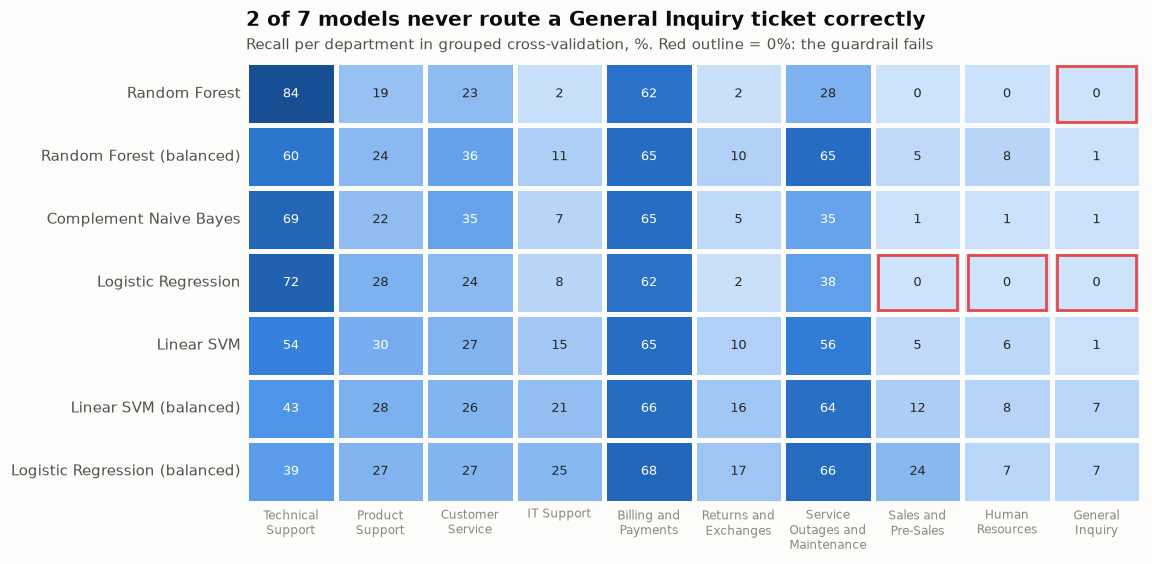

In [28]:
# Step 16 (guardrail, visible) — every model's recall per department in cross-validation
import textwrap

heat_df = recall_table.loc[models_only.sort_values("accuracy", ascending=False).index, list(dept_counts.index)] * 100
n_never = int((recall_table.loc[models_only.index, "General Inquiry"] == 0).sum())

fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.heatmap(heat_df, annot=True, fmt=".0f", cmap=BLUES, vmin=0, vmax=100, cbar=False, linewidths=2,
            linecolor=SURFACE, annot_kws={"fontsize": 8.5}, ax=ax)
for yi, name in enumerate(heat_df.index):
    for xi, v in enumerate(heat_df.loc[name]):
        if v == 0:
            ax.add_patch(plt.Rectangle((xi + 0.06, yi + 0.06), 0.88, 0.88, fill=False, edgecolor=CAT[7], linewidth=1.8))
ax.grid(False)
ax.tick_params(length=0)
ax.set_xticklabels([textwrap.fill(d, 12) for d in heat_df.columns], rotation=0, fontsize=8)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"{n_never} of {len(heat_df)} models never route a General Inquiry ticket correctly", pad=24)
ax.text(0, 1.03, "Recall per department in grouped cross-validation, %. Red outline = 0%: the guardrail fails",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()

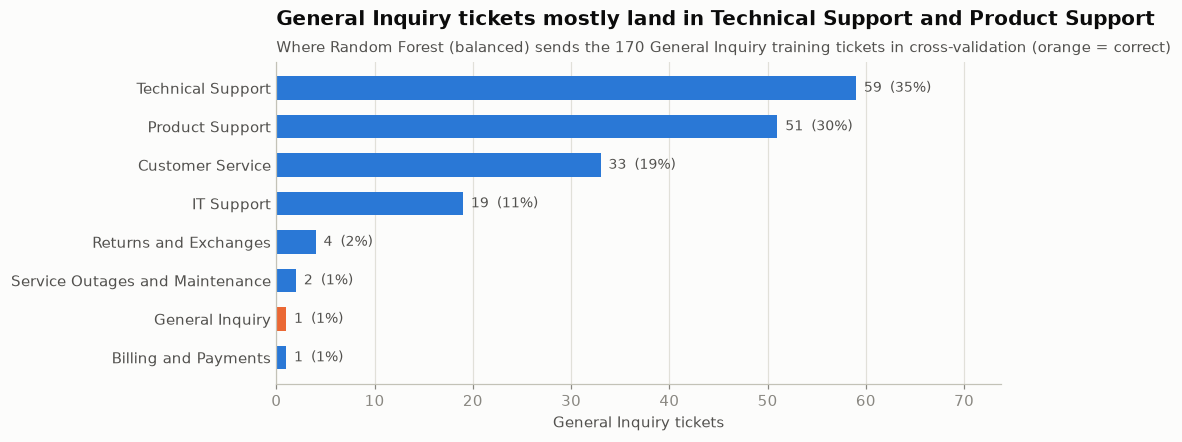

Most distinctive words (Step 13):
  General Inquiry      engagement, improve, audience, our, enhance, smart home, results, home
  Technical Support    issue, software, the issue, problem, restarting, issues, breach, the problem
  Product Support      engagement, targeting, not, brand, campaign, campaigns, results, efforts to


In [29]:
# Step 16 (diagnosis) — where do General Inquiry tickets actually go?
diagnosed = BEST_BASELINE or models_only["accuracy"].idxmax()
is_gi = (y_train == "General Inquiry").to_numpy()
routed = pd.Series(cv_preds[diagnosed][is_gi]).value_counts()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
colors = [CAT[1] if d == "General Inquiry" else CAT[0] for d in routed.index[::-1]]
ax.barh(routed.index[::-1], routed.values[::-1], height=0.6, color=colors)
for yi, v in enumerate(routed.values[::-1]):
    ax.text(v + 0.8, yi, f"{v}  ({v / is_gi.sum():.0%})", va="center", fontsize=9, color=INK_2)
ax.set_xlim(0, routed.max() * 1.25)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("General Inquiry tickets")
ax.set_title(f"General Inquiry tickets mostly land in {routed.index[0]}"
             + (f" and {routed.index[1]}" if len(routed) > 1 else ""), pad=24)
ax.text(0, 1.03, f"Where {diagnosed} sends the {is_gi.sum()} General Inquiry training tickets in cross-validation "
        "(orange = correct)", transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()

print("Most distinctive words (Step 13):")
for dept in ["General Inquiry", routed.index[0]] + ([routed.index[1]] if len(routed) > 1 else []):
    if dept in distinctive:
        print(f"  {dept:20s} {distinctive[dept]}")

In [30]:
# Step 16 (confirm) — train the selected model on all of train, score once on validation
confirmed = BEST_BASELINE or models_only["accuracy"].idxmax()
val_rows = {}
for name in ["Dummy — always biggest", "Dummy — random by size", confirmed]:
    model = clone(candidates[name]).fit(X_train, y_train)
    metrics, recalls = evaluate(y_val, model.predict(X_val))
    val_rows[name] = {**metrics, "General Inquiry found": f"{int(round(recalls[list(departments).index('General Inquiry')] * (y_val == 'General Inquiry').sum()))} "
                                                           f"of {(y_val == 'General Inquiry').sum()}"}
    if name == confirmed:
        selected_model = model

confirmation = pd.DataFrame({"cross-validation (train)": cv_results.loc[confirmed, ["accuracy", "macro F1", "weighted F1", "lowest department recall"]],
                             "validation": pd.Series(val_rows[confirmed])[["accuracy", "macro F1", "weighted F1", "lowest department recall"]]})
print(f"{confirmed}: does the validation set agree with cross-validation?")
display(confirmation.astype(float).round(3))
pd.DataFrame(val_rows).T.drop(columns=["weakest department"]).round(3)

Random Forest (balanced): does the validation set agree with cross-validation?


,cross-validation (train),validation
accuracy,0.384,0.406
macro F1,0.287,0.302
weighted F1,0.359,0.379
lowest department recall,0.006,0.000


,accuracy,macro F1,weighted F1,lowest department recall,General Inquiry found
Dummy — always biggest,0.29006,0.044968,0.130435,0.0,0 of 33
Dummy — random by size,0.180805,0.107684,0.180082,0.0,1 of 33
Random Forest (balanced),0.40617,0.302302,0.379315,0.0,0 of 33


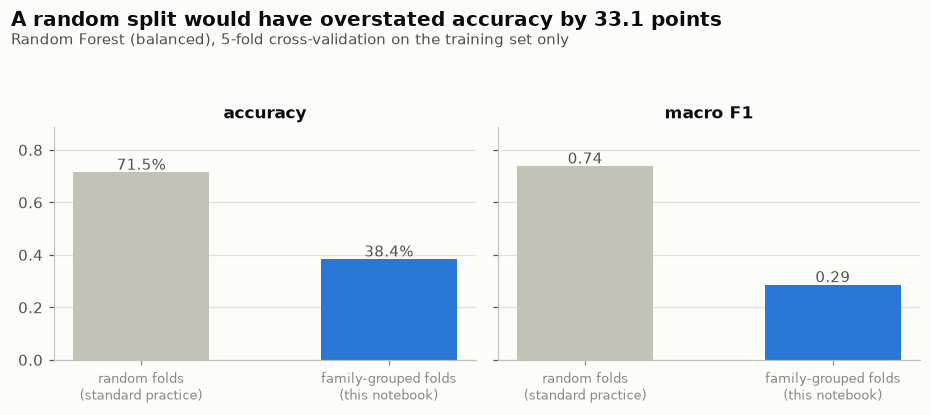

,accuracy,macro F1
random folds\n(standard practice),0.715,0.738
family-grouped folds\n(this notebook),0.384,0.286


In [31]:
# Step 16 (inflation) — what a standard random split would have claimed; training set only, test stays sealed
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), clone(candidates[confirmed]))
cv_schemes = {
    "random folds\n(standard practice)": KFold(n_splits=5, shuffle=True, random_state=SEED),
    "family-grouped folds\n(this notebook)": StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED),
}
cv_scores = {}
for name, cv in cv_schemes.items():
    s = cross_validate(pipeline, train_df["text"], y_train,
                       groups=train_df["family_id"] if isinstance(cv, StratifiedGroupKFold) else None, cv=cv,
                       scoring={"accuracy": "accuracy", "macro F1": "f1_macro"}, n_jobs=-1)
    cv_scores[name] = {"accuracy": s["test_accuracy"].mean(), "macro F1": s["test_macro F1"].mean()}
cv_scores = pd.DataFrame(cv_scores).T
inflation = cv_scores.iloc[0] - cv_scores.iloc[1]

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8), sharey=True)
for ax, metric, fmt in zip(axes, ["accuracy", "macro F1"], ["{:.1%}", "{:.2f}"]):
    ax.bar(range(2), cv_scores[metric], width=0.55, color=[AXIS, CAT[0]])
    for xi, v in enumerate(cv_scores[metric]):
        ax.text(xi, v + 0.01, fmt.format(v), ha="center", fontsize=9.5, color=INK_2)
    ax.set_xticks(range(2), cv_scores.index, fontsize=8.5)
    ax.set_title(metric, fontsize=11, loc="center")
    ax.grid(axis="x", visible=False)
axes[0].set_ylim(0, max(cv_scores.max()) * 1.2)
fig.suptitle(f"A random split would have overstated accuracy by {inflation['accuracy'] * 100:.1f} points",
             x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.text(0.01, 0.9, f"{confirmed}, 5-fold cross-validation on the training set only",
         fontsize=9.5, color=INK_2)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

cv_scores.round(3)

### What Phase 4 tells us

| | Accuracy | Macro F1 |
|---|---|---|
| Floor (dummies, cross-validation) | 29.0% | 0.10 |
| **Selected: Random Forest (balanced)** — cross-validation | **38.4%** | **0.29** |
| Same model — validation (confirmation) | 40.6% | 0.30 |
| Same model — *if we had used a random split* | *71.5%* | *0.74* |

- **The selection.** Random Forest (balanced) and Complement Naive Bayes tie on accuracy (38.4%); the tie is
  broken by macro F1 (0.29 vs 0.25). Validation agrees with cross-validation within about 2 points — the
  result is stable. The model beats the accuracy floor by about 9 points and triples the macro-F1 floor.
- **The headline number of this whole project: a random split would have claimed 71.5% accuracy.** Keeping
  families of reworded tickets apart drops it to 38.4%. The 33-point gap is the model recognising rewordings
  of tickets it trained on — not understanding departments. A notebook that skipped Step 10 would have
  published 71.5%.
- **The guardrail is passed by the narrowest possible margin.** Random Forest (balanced) routes **1 of 170**
  General Inquiry tickets correctly in cross-validation, and **0 of 33** on validation. Two models (unweighted
  Random Forest and Logistic Regression) never find General Inquiry at all. By the letter of the rule the
  selected model qualifies; in substance, **General Inquiry cannot be learned from this text.**
- **Why:** General Inquiry tickets land in Technical Support, Product Support and Customer Service. Their most
  distinctive words — *engagement, improve, audience, results* — are the same marketing-flavoured words that
  define Product Support. There is nothing in the text that marks them out.
- **Which departments are learnable:** Billing and Payments (~65% recall) and Service Outages (~65%) are
  consistently found — they have their own vocabulary. Human Resources, Sales and General Inquiry are rarely
  found by any model — the same departments whose labels looked keyword-driven in Steps 4 and 13.

**What carries forward:** *superseded.* These results made the department label itself look suspect —
the Checkpoint below tests that directly, and changes the target.

---
# Checkpoint — Is the target column trustworthy?

## Why we're changing course

**What we set out to do:** read a support ticket and route it to the right department.

**What we found on the way:** the department written on each ticket often has little to do with what the
ticket says. A hospital security breach filed under *Human Resources*. A question about investment returns
filed under *Returns and Exchanges*. The same ticket, reworded, filed under two different departments. The
best honest model gets only 38% of departments right — and one department it essentially never finds.

**Why carrying on would mislead:** a model can only learn a pattern that exists. If the labels don't follow
from the text, then tuning, calibrating and polishing a department classifier would produce more decimal
places on a number that measures the dataset's quirks, not a skill anyone could use. Worse, the easy version of
this project — a random split — would have reported 71% and looked like a success.

**What a data scientist does at this point:** stop, and test the label itself before spending more effort on
models. That is what this checkpoint does. If the text is to blame, no target will work; if the label is to
blame, a different label from the same data should be learnable. The test below shows it's the label.

**What changes, and what doesn't:**

| | |
|---|---|
| **Changes** | The modelling target: department (`queue`) → ticket **type** (Incident / Request / Problem / Change) |
| **Stays** | Everything in Phases 1–4 — kept as the investigation that found the problem |
| **Stays** | The rules: English only, families kept whole, test set sealed, accuracy decides with a guardrail |
| **Next** | Split, features and baselines are rebuilt for `type`; then tuning, error analysis, calibration and the final test |

A switch like this is only honest if it's shown in the open, with the evidence — which is why the department
work stays in the notebook rather than being quietly replaced.

### The evidence so far

> **Plain statement: the department column (`queue`) in this dataset does not reliably match the ticket text.**
> The technical name is **label noise** — tickets filed under a department their content doesn't support.
> Phases 1–4 above are kept exactly as they ran: they are the investigation that uncovered it.

Every phase added a piece of evidence. Together they point the same way:

| Where | What we saw | What it means |
|---|---|---|
| Step 3 | Tags written *after* reading the ticket predict the department only moderately | Even a human-written summary of the ticket doesn't line up with its department |
| Step 4 | About 12 of 20 sampled tickets plausibly belonged to their department — *Human Resources* held a security breach | Labels contradict the text by eye |
| Step 10 | Near-identical rewordings of the same problem filed under IT Support in one wording, Technical Support in another | The same text, two answers |
| Step 13 | *Returns and Exchanges* is defined by the words "investment returns" | Departments seem to have been assigned by surface keywords |
| Step 16 | The best model reaches 38% against a 29% floor; General Inquiry is essentially never found | Little of the department is learnable from the text |

**What it is not:** it is not the models, and it is not the text. The test below proves both, by asking the
same models to predict *other* columns from the *same* text, with the same honest family-grouped evaluation.

In [32]:
# Checkpoint (test) — which column can actually be predicted from the ticket text? Training set only.
import warnings

coarse_department = {
    "Technical Support": "Tech / IT / Product", "IT Support": "Tech / IT / Product", "Product Support": "Tech / IT / Product",
    "Customer Service": "Customer / Sales / General", "Sales and Pre-Sales": "Customer / Sales / General",
    "General Inquiry": "Customer / Sales / General", "Billing and Payments": "Billing", "Returns and Exchanges": "Returns",
    "Service Outages and Maintenance": "Outages", "Human Resources": "HR",
}
target_candidates = {
    "queue — department, 10 (current)": train_df["queue"],
    "queue merged into 6 groups": train_df["queue"].map(coarse_department),
    "type — Incident / Request / Problem / Change": train_df["type"],
    "priority — low / medium / high": train_df["priority"],
    "tag_1 — first tag (many values)": train_df["tag_1"],
}
multi_member = train_df["family_id"].map(train_df["family_id"].value_counts()) > 1

target_rows = {}
for name, target in target_candidates.items():
    target = target.astype(str)
    with warnings.catch_warnings():  # rare tag values trigger "fewer members than folds" warnings; harmless here
        warnings.simplefilter("ignore")
        pred = cross_val_predict(make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), LogisticRegression(max_iter=2000)),
                                 train_df["text"], target, groups=train_df["family_id"], cv=GROUPED_CV, n_jobs=-1)
    in_families = target[multi_member].groupby(train_df.loc[multi_member, "family_id"])
    target_rows[name] = {
        "classes": target.nunique(),
        "accuracy": accuracy_score(target, pred),
        "accuracy floor": target.value_counts(normalize=True).iloc[0],
        "macro F1": f1_score(target, pred, average="macro"),
        "macro-F1 floor": 1 / target.nunique(),
        "same label across rewordings": in_families.agg(lambda s: s.value_counts(normalize=True).iloc[0]).mean(),
    }
target_check = pd.DataFrame(target_rows).T.astype(float)
target_check["gain over floor (pts)"] = (target_check["accuracy"] - target_check["accuracy floor"]) * 100
target_check.round(3)

,classes,accuracy,accuracy floor,macro F1,macro-F1 floor,same label across rewordings,gain over floor (pts)
"queue — department, 10 (current)",10.0,0.383,0.290,0.242,0.100,0.981,9.306
queue merged into 6 groups,6.0,0.668,0.597,0.370,0.167,0.987,7.087
type — Incident / Request / Problem / Change,4.0,0.792,0.409,0.773,0.250,0.994,38.260
priority — low / medium / high,3.0,0.455,0.401,0.384,0.333,0.983,5.467
tag_1 — first tag (many values),69.0,0.762,0.200,0.120,0.014,0.902,56.178


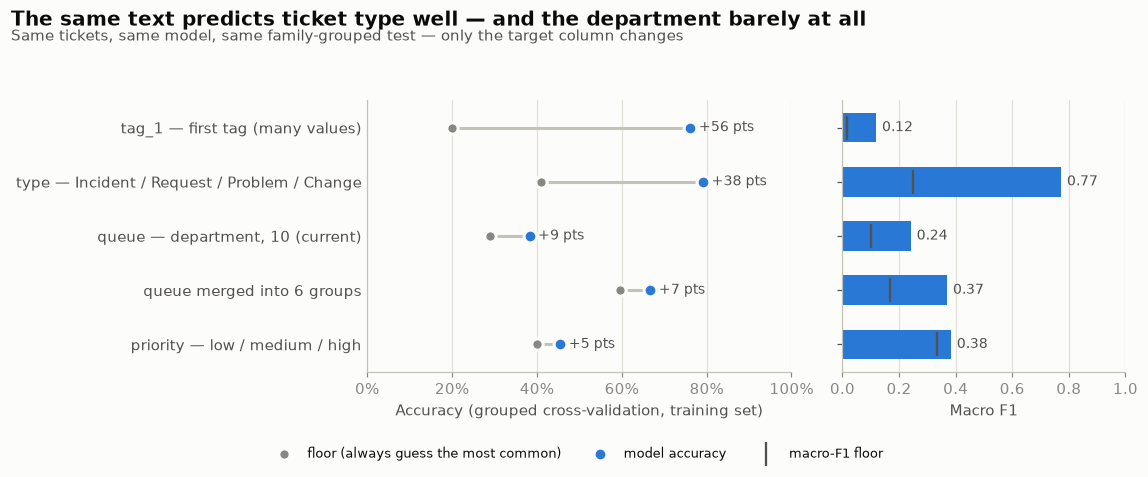

In [33]:
# Checkpoint (chart) — accuracy against each column's own floor, and macro F1
order = target_check.sort_values("gain over floor (pts)").index
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True, gridspec_kw={"width_ratios": [1.5, 1]})
y = np.arange(len(order))

ax1.hlines(y, target_check.loc[order, "accuracy floor"], target_check.loc[order, "accuracy"], color=AXIS, linewidth=2)
ax1.scatter(target_check.loc[order, "accuracy floor"], y, s=55, color=MUTED, edgecolor=SURFACE, linewidth=2, zorder=3, label="floor (always guess the most common)")
ax1.scatter(target_check.loc[order, "accuracy"], y, s=70, color=CAT[0], edgecolor=SURFACE, linewidth=2, zorder=3, label="model accuracy")
for yi, name in zip(y, order):
    ax1.text(target_check.loc[name, "accuracy"] + 0.02, yi, f"+{target_check.loc[name, 'gain over floor (pts)']:.0f} pts",
             va="center", fontsize=9, color=INK_2)
ax1.set_xlim(0, 1)
ax1.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax1.set_yticks(y, order)
ax1.tick_params(axis="y", length=0)
ax1.grid(axis="y", visible=False)
ax1.set_xlabel("Accuracy (grouped cross-validation, training set)")

ax2.barh(y, target_check.loc[order, "macro F1"], height=0.55, color=CAT[0])
ax2.scatter(target_check.loc[order, "macro-F1 floor"], y, marker="|", s=250, color=INK_2, zorder=3, label="macro-F1 floor")
for yi, name in zip(y, order):
    ax2.text(target_check.loc[name, "macro F1"] + 0.02, yi, f"{target_check.loc[name, 'macro F1']:.2f}", va="center", fontsize=9, color=INK_2)
ax2.set_xlim(0, 1)
ax2.grid(axis="y", visible=False)
ax2.set_xlabel("Macro F1")

fig.suptitle("The same text predicts ticket type well — and the department barely at all", x=0.01, ha="left",
             fontweight="bold", fontsize=13)
fig.text(0.01, 0.915, "Same tickets, same model, same family-grouped test — only the target column changes",
         fontsize=9.5, color=INK_2)
handles = [h for a in (ax1, ax2) for h in a.get_legend_handles_labels()[0]]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=8.5, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.06, 1, 0.9))
plt.show()

### Reading the test

- **The text is informative.** From the same words, the model predicts ticket **type** far above its floor.
- **The department is the problem.** It barely beats its floor. And **merging look-alike departments doesn't
  help** — if the only issue were similar-sounding departments, merging them would fix it. It doesn't, so the
  department labels are, to a large extent, unrelated to what the ticket says.
- **The labels are consistent, just not with the content.** Rewordings of one ticket almost always share the
  same department (the last column). The generator seems to have picked a department once per original ticket
  and copied it to every rewording — so the noise is *consistent* noise, which is exactly why a random split
  could memorise it (Step 16) and why no honest model can learn it.
- **`priority` is also weakly tied to the text**, and **`tag_1`** scores well on accuracy but has dozens of
  values, a very low macro F1, and changes between rewordings — a descriptive tag, not a routing decision.

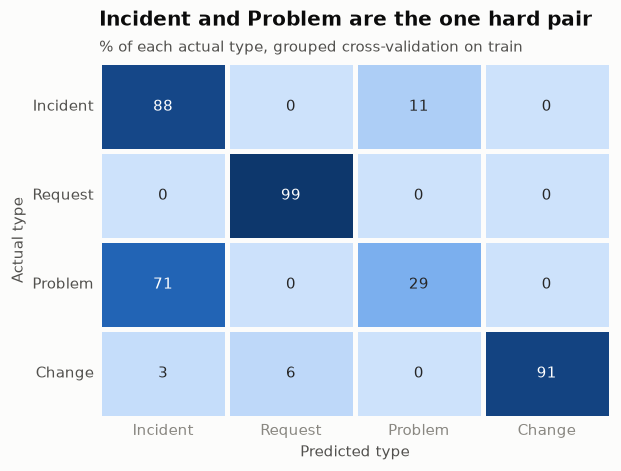

              precision    recall  f1-score   support

    Incident      0.705     0.884     0.784      4775
     Request      0.972     0.993     0.982      3203
     Problem      0.561     0.288     0.381      2446
      Change      0.984     0.912     0.946      1246

    accuracy                          0.792     11670
   macro avg      0.805     0.769     0.773     11670
weighted avg      0.778     0.792     0.771     11670



In [34]:
# Checkpoint (type up close) — per-class scores for the proposed target, and which types get confused
from sklearn.metrics import classification_report, confusion_matrix

type_pred = cross_val_predict(make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), LogisticRegression(max_iter=2000)),
                              train_df["text"], train_df["type"], groups=train_df["family_id"], cv=GROUPED_CV, n_jobs=-1)
type_order = ["Incident", "Request", "Problem", "Change"]
type_cm = pd.DataFrame(confusion_matrix(train_df["type"], type_pred, labels=type_order, normalize="true") * 100,
                       index=type_order, columns=type_order)

fig, ax = plt.subplots(figsize=(6, 4.2))
sns.heatmap(type_cm, annot=True, fmt=".0f", cmap=BLUES, vmin=0, vmax=100, cbar=False, linewidths=2,
            linecolor=SURFACE, annot_kws={"fontsize": 10}, ax=ax)
ax.grid(False)
ax.tick_params(length=0)
ax.set_yticklabels(type_order, rotation=0)
ax.set_xlabel("Predicted type")
ax.set_ylabel("Actual type")
ax.set_title("Incident and Problem are the one hard pair", pad=24)
ax.text(0, 1.03, "% of each actual type, grouped cross-validation on train", transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()

print(classification_report(train_df["type"], type_pred, labels=type_order, digits=3))

### Decision: the modelling target becomes `type`

> **From here on, the model predicts the ticket's `type` — Incident, Request, Problem or Change.**
> The department (`queue`) results above stay in the notebook as the evidence for this decision.

**Why `type`:**

1. **It is learnable from the text** — about 80% accuracy against a 41% floor, under the same honest,
   family-grouped evaluation that held the department to 38%.
2. **It is the most consistent label in the dataset** — rewordings of the same ticket carry the same type
   more than 99% of the time.
3. **It is a real routing decision.** In IT service management, type decides *which process* a ticket enters:
   Incidents go to the on-call / restore-service queue, Requests to the service desk, Changes to change
   management, Problems to root-cause investigation. Getting it right is genuinely useful.
4. **Its weak spot is honest and explainable.** Incident vs Problem is the one confused pair — and it is a
   real ambiguity: a Problem is the underlying cause behind repeated Incidents, and people mix them up too.

**What this does not change:** `type` stays **banned as a model input** (Step 3) — using it as the *target*
is a different thing; every label is assigned by someone after reading the ticket. The text, the English-only
scope, the families, the split method and the evaluation rules all carry over unchanged.

**What it costs, stated plainly:** this is no longer a *department* router. The honest summary of this project
becomes: *"the dataset's department labels turned out not to match its tickets; I proved it, and built the
classifier on the label that does."*

---
# Phase 4B — Rebuild on the new target: ticket `type`

Same data, same rules, new target. From here on the model predicts **Incident, Request, Problem or Change**.

| | Carried over unchanged | Changed for `type` |
|---|---|---|
| Data | 16,338 English tickets, cleaned text, `family_id` | — |
| Split | Grouped by family, 71 / 14 / 14 | **Re-drawn, stratified by `type`** (see below) |
| Features | Same TF-IDF settings | Refit on the new training set |
| Models | Same 7 models + 2 dummies, weighted and unweighted | — |
| Selection | Grouped CV on train; accuracy decides; guardrail = every class found at least sometimes; ties within 1 point → macro F1 → probabilities | — |

**Why the split is re-drawn.** The Phase 3 split kept *departments* balanced, not types: its test set came out
with 36% Incidents against 41% in train, and 34% Requests against 27%. A test set with a different mix would
distort the final score. Re-drawing it is legitimate here because **the test set has never been opened** — no
model has been scored on it. The new split is drawn once, with the same seed, before any `type` model is trained.

In [35]:
# Phase 4B (split) — re-draw train / validation / test, stratified by type, grouped by family; verify
LABEL = "type"  # the target from here on
TYPES = np.array(["Incident", "Request", "Problem", "Change"])

y_all, groups = df[LABEL].to_numpy(), df["family_id"].to_numpy()
rest_idx, test_idx = next(StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED).split(np.arange(len(df)), y_all, groups))
tr, va = next(StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED).split(rest_idx, y_all[rest_idx], groups[rest_idx]))
train_df, val_df, test_df = df.iloc[rest_idx[tr]], df.iloc[rest_idx[va]], df.iloc[test_idx]
y_train, y_val, y_test = train_df[LABEL], val_df[LABEL], test_df[LABEL]

splits = {"train": train_df, "validation": val_df, "test": test_df}
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    assert not set(splits[a]["family_id"]) & set(splits[b]["family_id"]), f"a family appears in both {a} and {b}"
print("No family crosses splits ✓")

mixed = df.groupby("family_id")[LABEL].nunique().gt(1)
print(f"Families holding more than one type: {mixed.sum():,} ({df['family_id'].map(mixed).sum():,} tickets) — kept as labelled\n")

type_split = pd.DataFrame({n: s[LABEL].value_counts(normalize=True).mul(100) for n, s in splits.items()}).loc[TYPES]
print(f"Largest difference in any type's share across splits: {(type_split.max(axis=1) - type_split.min(axis=1)).max():.2f} points")
type_split.loc["— tickets —"] = [len(s) for s in splits.values()]
type_split.round(1)

No family crosses splits ✓
Families holding more than one type: 70 (1,105 tickets) — kept as labelled

Largest difference in any type's share across splits: 0.04 points


,train,validation,test
type,,,
Incident,40.2,40.2,40.2
Request,28.6,28.5,28.5
Problem,20.8,20.8,20.8
Change,10.4,10.5,10.5
— tickets —,11670.0,2334.0,2334.0


In [36]:
# Phase 4B (features) — refit TF-IDF on the new training set; the words that set each type apart
vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])
print(f"Vocabulary learned from train: {len(vectorizer.vocabulary_):,} words and word pairs\n")

terms = vectorizer.get_feature_names_out()
type_words = {}
for t in TYPES:
    in_type = (y_train == t).to_numpy()
    lift = np.asarray(X_train[in_type].mean(axis=0)).ravel() - np.asarray(X_train[~in_type].mean(axis=0)).ravel()
    type_words[t] = ", ".join(terms[np.argsort(lift)[::-1][:10]])
pd.Series(type_words, name="most distinctive words and word pairs").to_frame()

Vocabulary learned from train: 43,077 words and word pairs



,most distinctive words and word pairs
Incident,"issue, have, recent, the issue, problem, has, system, been, due to, due"
Request,"you, on, could you, for, you provide, about, information on, information, details, provide"
Problem,"due to, due, problem, issue, have, facing, despite, issues, be due, might"
Change,"improve, request, enhance, current, update, for, our, an update, enhancements, to improve"


In [37]:
# Phase 4B (models) — every candidate scored with grouped cross-validation on the new training set
type_rows, type_preds = {}, {}
for name, model in candidates.items():
    start = time.perf_counter()
    pipeline = make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), clone(model))
    pred = cross_val_predict(pipeline, train_df["text"], y_train, groups=train_df["family_id"], cv=GROUPED_CV, n_jobs=-1)
    metrics, _ = evaluate(y_train, pred, labels=TYPES)
    type_rows[name] = {**metrics, "seconds": time.perf_counter() - start}
    type_preds[name] = pred

type_results = pd.DataFrame(type_rows).T.astype({"accuracy": float, "macro F1": float, "weighted F1": float,
                                                 "lowest department recall": float, "seconds": float})
type_results = type_results.rename(columns={"lowest department recall": "lowest type recall", "weakest department": "weakest type"})
type_results["passes guardrail"] = type_results["lowest type recall"] > 0
type_results.sort_values("accuracy", ascending=False).round(3)

,accuracy,macro F1,weighted F1,lowest type recall,weakest type,seconds,passes guardrail
Logistic Regression,0.796,0.780,0.779,0.320,Problem,4.116,True
Linear SVM,0.794,0.793,0.786,0.396,Problem,2.180,True
Linear SVM (balanced),0.792,0.798,0.787,0.443,Problem,1.887,True
Logistic Regression (balanced),0.788,0.805,0.790,0.566,Problem,3.785,True
Random Forest (balanced),0.786,0.763,0.766,0.286,Problem,20.447,True
Random Forest,0.771,0.675,0.698,0.029,Problem,20.949,True
Complement Naive Bayes,0.765,0.665,0.693,0.037,Problem,1.469,True
Dummy — always biggest,0.402,0.143,0.231,0.000,Request,2.637,False
Dummy — random by size,0.300,0.251,0.299,0.108,Change,2.667,True


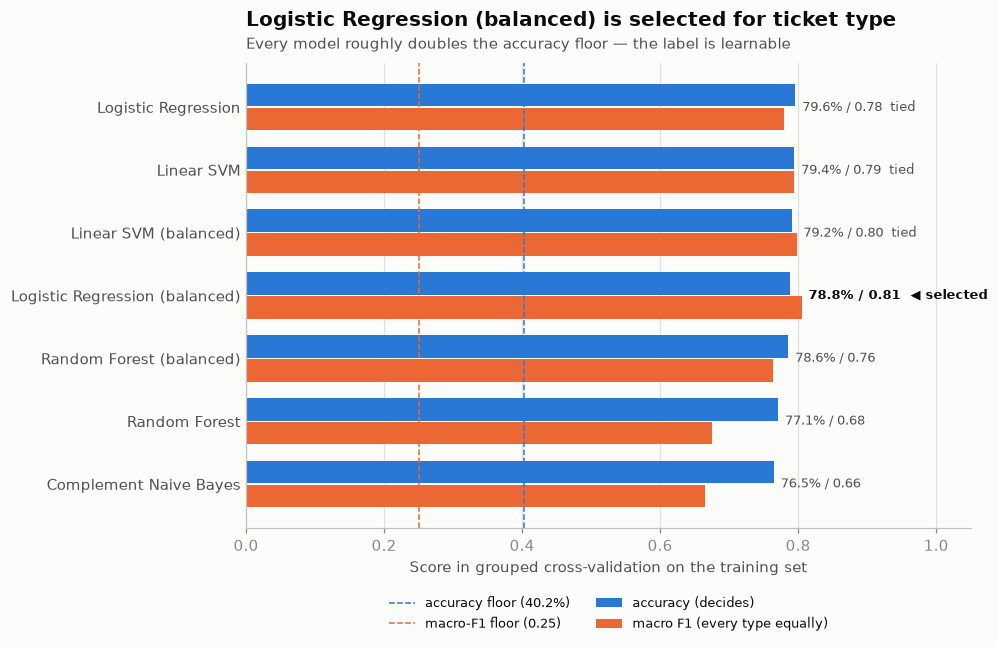

Selected: Logistic Regression (balanced)


,accuracy,macro F1,weighted F1,lowest type recall,weakest type,seconds,passes guardrail,gives probabilities
Logistic Regression,0.796,0.780,0.779,0.320,Problem,4.116,True,True
Logistic Regression (balanced),0.788,0.805,0.790,0.566,Problem,3.785,True,True
Linear SVM,0.794,0.793,0.786,0.396,Problem,2.180,True,False
Linear SVM (balanced),0.792,0.798,0.787,0.443,Problem,1.887,True,False


In [38]:
# Phase 4B (select) — same rule as Step 16: guardrail, accuracy, 1-point ties → macro F1 → probabilities
TYPE_FLOOR_ACCURACY = type_results.loc["Dummy — always biggest", "accuracy"]
TYPE_FLOOR_MACRO_F1 = type_results.loc["Dummy — random by size", "macro F1"]
type_models = type_results[~type_results.index.str.startswith("Dummy")]
type_qualifying = type_models[type_models["passes guardrail"]]
type_tied = type_qualifying[type_qualifying["accuracy"] >= type_qualifying["accuracy"].max() - TIE_TOLERANCE].copy()
type_tied["gives probabilities"] = [hasattr(candidates[n], "predict_proba") for n in type_tied.index]
BEST_TYPE_MODEL = type_tied.sort_values(["macro F1", "gives probabilities"], ascending=False).index[0]

plot_df = type_models.sort_values("accuracy")
fig, ax = plt.subplots(figsize=(8.5, 5.5))
y = np.arange(len(plot_df))
ax.barh(y + 0.19, plot_df["accuracy"], height=0.36, color=CAT[0], label="accuracy (decides)")
ax.barh(y - 0.19, plot_df["macro F1"], height=0.36, color=CAT[1], label="macro F1 (every type equally)")
ax.axvline(TYPE_FLOOR_ACCURACY, color=CAT[0], linestyle="--", linewidth=1, label=f"accuracy floor ({TYPE_FLOOR_ACCURACY:.1%})")
ax.axvline(TYPE_FLOOR_MACRO_F1, color=CAT[1], linestyle="--", linewidth=1, label=f"macro-F1 floor ({TYPE_FLOOR_MACRO_F1:.2f})")
for yi, (name, r) in zip(y, plot_df.iterrows()):
    note = ("  ◀ selected" if name == BEST_TYPE_MODEL else "  tied" if name in type_tied.index
            else "" if r["passes guardrail"] else f"  ✗ never finds {r['weakest type']}")
    ax.text(max(r["accuracy"], r["macro F1"]) + 0.01, yi, f"{r['accuracy']:.1%} / {r['macro F1']:.2f}{note}", va="center",
            fontsize=8.5, color=INK if name == BEST_TYPE_MODEL else INK_2, fontweight="bold" if name == BEST_TYPE_MODEL else "normal")
ax.set_yticks(y, plot_df.index)
ax.set_xlim(0, 1.05)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Score in grouped cross-validation on the training set")
ax.set_title(f"{BEST_TYPE_MODEL} is selected for ticket type", pad=24)
ax.text(0, 1.03, "Every model roughly doubles the accuracy floor — the label is learnable",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8.5)
plt.show()

print(f"Selected: {BEST_TYPE_MODEL}")
type_tied.round(3)

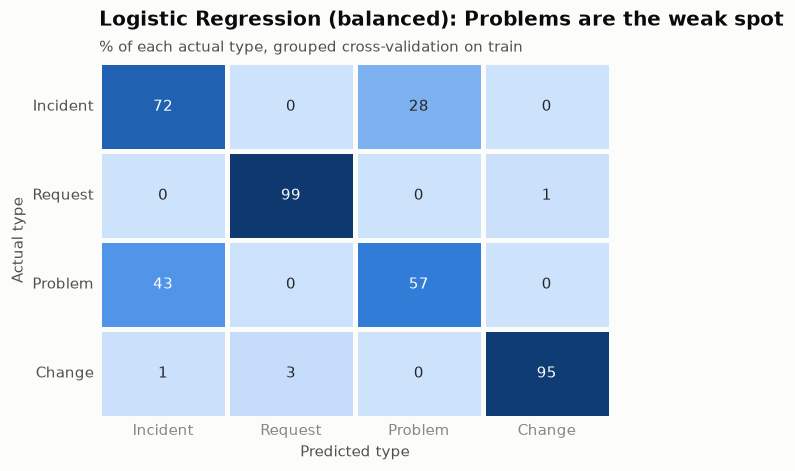

              precision    recall  f1-score   support

    Incident      0.761     0.719     0.739      4694
     Request      0.984     0.987     0.985      3333
     Problem      0.510     0.566     0.537      2426
      Change      0.963     0.954     0.959      1217

    accuracy                          0.788     11670
   macro avg      0.805     0.806     0.805     11670
weighted avg      0.794     0.788     0.790     11670



In [39]:
# Phase 4B (errors) — where the selected model goes wrong, by type (cross-validation on train)
sel_cm = pd.DataFrame(confusion_matrix(y_train, type_preds[BEST_TYPE_MODEL], labels=TYPES, normalize="true") * 100,
                      index=TYPES, columns=TYPES)
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.heatmap(sel_cm, annot=True, fmt=".0f", cmap=BLUES, vmin=0, vmax=100, cbar=False, linewidths=2,
            linecolor=SURFACE, annot_kws={"fontsize": 10}, ax=ax)
ax.grid(False)
ax.tick_params(length=0)
ax.set_yticklabels(TYPES, rotation=0)
ax.set_xlabel("Predicted type")
ax.set_ylabel("Actual type")
ax.set_title(f"{BEST_TYPE_MODEL}: Problems are the weak spot", pad=24)
ax.text(0, 1.03, "% of each actual type, grouped cross-validation on train", transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()
print(classification_report(y_train, type_preds[BEST_TYPE_MODEL], labels=TYPES, digits=3))

In [40]:
# Phase 4B (confirm) — train the selected model on all of train, score once on validation
type_val = {}
for name in ["Dummy — always biggest", "Dummy — random by size", BEST_TYPE_MODEL]:
    model = clone(candidates[name]).fit(X_train, y_train)
    type_val[name], _ = evaluate(y_val, model.predict(X_val), labels=TYPES)
    if name == BEST_TYPE_MODEL:
        selected_type_model = model
cols = ["accuracy", "macro F1", "weighted F1", "lowest department recall"]
print(f"{BEST_TYPE_MODEL}: does validation agree with cross-validation?")
display(pd.DataFrame({"cross-validation (train)": type_results.loc[BEST_TYPE_MODEL].rename({"lowest type recall": "lowest department recall"})[cols],
                      "validation": pd.Series(type_val[BEST_TYPE_MODEL])[cols]}).rename(index={"lowest department recall": "lowest type recall"}).astype(float).round(3))
pd.DataFrame(type_val).T.rename(columns={"lowest department recall": "lowest type recall", "weakest department": "weakest type"}).round(3)

Logistic Regression (balanced): does validation agree with cross-validation?


,cross-validation (train),validation
accuracy,0.788,0.790
macro F1,0.805,0.807
weighted F1,0.790,0.792
lowest type recall,0.566,0.577


,accuracy,macro F1,weighted F1,lowest type recall,weakest type
Dummy — always biggest,0.402314,0.143446,0.230842,0.0,Request
Dummy — random by size,0.303342,0.25464,0.302187,0.122951,Change
Logistic Regression (balanced),0.789632,0.807491,0.79232,0.57732,Problem


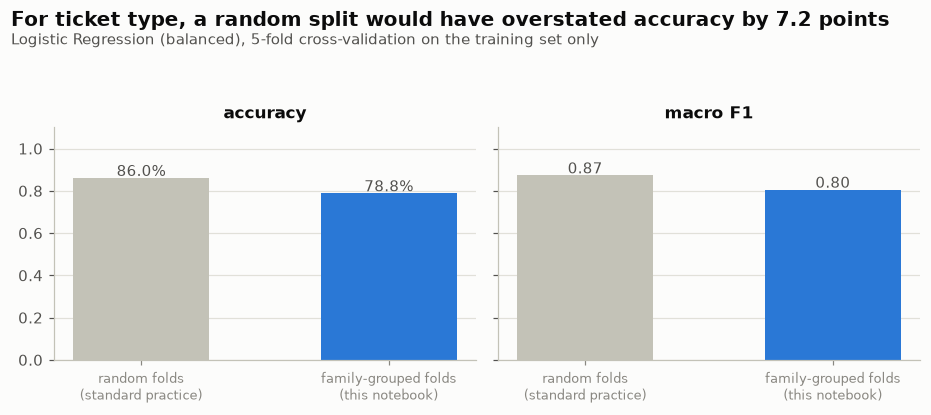

,accuracy,macro F1
random folds\n(standard practice),0.860,0.873
family-grouped folds\n(this notebook),0.788,0.805


In [41]:
# Phase 4B (inflation) — would a random split have flattered the type model too? Training set only
type_pipeline = make_pipeline(TfidfVectorizer(**TFIDF_PARAMS), clone(candidates[BEST_TYPE_MODEL]))
type_cv_scores = {}
for name, cv in cv_schemes.items():
    s = cross_validate(type_pipeline, train_df["text"], y_train,
                       groups=train_df["family_id"] if isinstance(cv, StratifiedGroupKFold) else None, cv=cv,
                       scoring={"accuracy": "accuracy", "macro F1": "f1_macro"}, n_jobs=-1)
    type_cv_scores[name] = {"accuracy": s["test_accuracy"].mean(), "macro F1": s["test_macro F1"].mean()}
type_cv_scores = pd.DataFrame(type_cv_scores).T
type_inflation = type_cv_scores.iloc[0] - type_cv_scores.iloc[1]

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8), sharey=True)
for ax, metric, fmt in zip(axes, ["accuracy", "macro F1"], ["{:.1%}", "{:.2f}"]):
    ax.bar(range(2), type_cv_scores[metric], width=0.55, color=[AXIS, CAT[0]])
    for xi, v in enumerate(type_cv_scores[metric]):
        ax.text(xi, v + 0.01, fmt.format(v), ha="center", fontsize=9.5, color=INK_2)
    ax.set_xticks(range(2), type_cv_scores.index, fontsize=8.5)
    ax.set_title(metric, fontsize=11, loc="center")
    ax.grid(axis="x", visible=False)
axes[0].set_ylim(0, 1.1)
fig.suptitle(f"For ticket type, a random split would have overstated accuracy by {type_inflation['accuracy'] * 100:.1f} points",
             x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.text(0.01, 0.9, f"{BEST_TYPE_MODEL}, 5-fold cross-validation on the training set only", fontsize=9.5, color=INK_2)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()
type_cv_scores.round(3)

### What Phase 4B tells us

| | Accuracy | Macro F1 |
|---|---|---|
| Floor (dummies, cross-validation) | 40.2% | 0.25 |
| **Selected: Logistic Regression (balanced)** — cross-validation | **78.8%** | **0.81** |
| Same model — validation (confirmation) | 79.0% | 0.81 |
| Same model — *if we had used a random split* | *86.0%* | *0.87* |

- **The new target works.** Every real model roughly doubles the accuracy floor. The selected model gets
  nearly 4 in 5 tickets' type right, and validation agrees with cross-validation almost exactly (79.0% vs 78.8%)
  — the result is stable, not a lucky split.
- **Why this model.** Four models are tied within 1 point of the best accuracy (79.6%). The tie-break — macro F1 —
  picks the balanced Logistic Regression. The trade is visible and small: **0.8 points of accuracy for finding
  far more Problems** (recall 57% instead of 32%). It also gives probabilities, which the confidence-based routing
  in Step 19 needs.
- **The words make sense.** Requests are written as questions (*could you, information on, provide details*),
  Changes as improvements (*enhance, update, improve*), Incidents and Problems as trouble (*issue, problem, due to*).
  The model is learning language that genuinely distinguishes the types — the opposite of the department picture.
- **The one weak spot is Incident vs Problem.** 43% of Problems are read as Incidents and 28% of Incidents as
  Problems. Their vocabulary overlaps (*issue, problem, due to*), and the distinction is subtle for people too:
  an Incident is "something broke", a Problem is "the underlying cause of things breaking". Requests (99%) and
  Changes (95%) are nearly perfect.
- **Memorisation is much smaller here.** A random split would have added 7 points — against 33 points for
  departments. When a label genuinely follows from the text, there is less to gain from memorising rewordings.

**What carries forward:** `BEST_TYPE_MODEL` (Logistic Regression, balanced) at 78.8% accuracy / 0.81 macro F1
in grouped cross-validation — the number Step 17's tuning has to beat. The new `train_df` / `val_df` / `test_df`,
`X_train` / `X_val` / `X_test` and `LABEL = "type"` are what every later step uses. The test set is still sealed.

---
> ### 🚧 Everything below this line is the original plan, written for departments
>
> Steps 17–20 were drafted before the checkpoint and still refer to departments. They will be rebuilt on
> `type` in the next phase — starting with a fresh split, features and baselines for `type` — before any of
> them run. Until then they are placeholders, and nothing below uses the test set.

---
# Phase 5 — Improve and diagnose
*Steps 17 to 19*

## Step 17 — Tune the best model

Search over the winner's settings to squeeze out more performance.

**Where to tune:** use **cross-validation on the training set, grouped by family** — not the validation set,
and definitely not the test set. Tuning repeatedly against validation slowly overfits to it. And the folds
must keep families whole, for the same reason as the split: otherwise tuning rewards settings that are
good at recognising rewordings.

**What to search:** the vectorizer settings and the model's regularisation strength together,
since they interact.

**`RandomizedSearchCV` over `GridSearchCV`** — it samples a fixed number of combinations
instead of trying every one. Far cheaper, and usually finds something just as good.

Compare the tuned score against the baseline score. If tuning gained you 0.3%, say so plainly
rather than presenting it as a breakthrough.

In [42]:
# Step 17 — RandomizedSearchCV over pipeline, report best params and gain vs baseline

## Step 18 — Error analysis

A single score hides *where* the model fails. Four things to look at, in order:

**1. Per-class scores.** Which departments is it bad at? Small classes usually. Name the
worst three explicitly.

**2. Confusion matrix.** Which pairs does it mix up? Context matters here — Billing confused
with Payments is understandable and might be acceptable in production. Billing confused with
HR would signal something genuinely broken.

**3. Read real misclassified tickets.** Often the most useful five minutes in the whole
notebook. A large share of "errors" turn out to be genuinely ambiguous tickets that two
departments could legitimately own — which means the ceiling is lower than 100% and that's
fine.

**4. Measure the label noise.** Steps 4 and 10 found early signs that some labels don't match their
text. Using cross-validated predictions on the training set (folds grouped by family), flag tickets the
model *confidently* assigns to a different department than their label — the idea behind *confident
learning*. Read a sample and count how many are genuine label errors. Also check scores on short tickets
(≤ 10 words) separately, since Step 6 kept them in.

Normalise the confusion matrix by row so each row sums to 1.0, otherwise the big classes
visually dominate and you can't see anything.

In [43]:
# Step 18a — per-class classification report, identify weakest classes

In [44]:
# Step 18b — normalised confusion matrix heatmap, list most-confused pairs

In [45]:
# Step 18c — print a handful of actual misclassified tickets to read

## Step 19 — Check and fix the confidence scores (calibration)

Getting the answer right is one thing. Knowing *how sure* it is, is another.

**A well-calibrated model that says "85% confident" is right about 85% of the time when it
says that.** That matters in production — it's what lets you auto-route the confident tickets
and send the uncertain ones to a human.

**Measure first:** Expected Calibration Error (ECE) — how far stated confidence drifts from
actual accuracy. Lower is better. Also track log-loss.

**Then fix if needed:** isotonic regression or Platt scaling, fitted on validation.

**Then check the fix actually helped.** It doesn't always. Calibration corrects a distortion —
if the model was already honest, applying it can make things worse. Only keep the calibrated
version if ECE genuinely improved, and say which way it went.

Plot a reliability curve before and after, with dot size showing how many tickets fall in each
confidence bin — otherwise a wild-looking line from a 3-ticket bin misleads you.

In [46]:
# Step 19a — compute ECE and log-loss before and after calibration, decide which to keep

In [47]:
# Step 19b — reliability curve plot, before vs after

---
# Phase 6 — Finalize
*Step 20*

## Step 20 — Final evaluation, save, and document

**The test set gets opened once, here.** Whatever number comes out is the number we report.
No going back to tune after seeing it — that's the entire reason it was held back.

**Report:**
- Accuracy, macro F1, weighted F1, ECE
- How far it beat the floors — recomputed **on the test set itself**, not carried over from Step 4

**Plot:**
- Final confusion matrix on test
- The journey: floor → best baseline → tuned → final. Shows how much was actually gained.

**Save:**
- The fitted model to `artifacts/`
- A **model card** as JSON

**The model card is not optional.** It should state plainly:
- What the model does and what data it was trained on
- Which languages it covers (and therefore which it doesn't)
- Its weakest departments, by name and score
- Which department pairs it confuses, and whether that's acceptable
- That it was trained on one dataset from one source and needs revalidation on real traffic

Writing down what a model *can't* do is what separates a professional result from a demo.

In [48]:
# Step 20a — predict on test set once, report all final metrics vs the floor

In [49]:
# Step 20b — final confusion matrix + progress-from-floor chart

In [50]:
# Step 20c — save model with joblib, write model_card.json with known limitations

---
## Done — and what comes next

**What we end up with:** a trained, tuned, calibration-checked department classifier,
evaluated once on data it never saw — in any wording — with its weaknesses written down honestly.

**Sensible next experiments:**

1. **Add German.** First detect families *across* languages (for example, with multilingual sentence
   embeddings), so translated tickets can't leak across the split — then compare against the English-only
   numbers. Does more data beat cleaner data here?
2. **Try a transformer** (e.g. a multilingual sentence model) against this baseline. Only
   worth adopting if it *clearly* beats these numbers — otherwise the classical model wins
   on cost and speed.
3. **Set a confidence threshold.** Auto-route tickets above it, send the rest to a human.
   Step 19's calibration is what makes that threshold trustworthy.
4. **Compare against Jev** on this exact test set, if API access comes through. That would
   turn the article's vendor-published numbers into first-hand ones.